In [1]:
import warnings
import importlib
import os
import sys
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import pandas as pd
import warnings
from IPython.display import display
import matplotlib.pyplot as plt
import json
import time

# **Check DWH connection**

In [2]:
warnings.filterwarnings('ignore', category=UserWarning, module='pandas')
load_dotenv(find_dotenv())
env_data_dir = os.getenv("DATA_DIR")
project_root = os.getenv('PROJECT_ROOT') 

if project_root not in sys.path:
    sys.path.append(project_root)

PROJECT_ROOT = os.getenv("PROJECT_ROOT")
IPAI_PROJECT_DIR = os.getenv("IPAI_PROJECT_DIR") 
BASE_DATA_DIR = Path(env_data_dir) if env_data_dir else project_root / "data"
CLEANED_CSV_DIR = BASE_DATA_DIR / "csv_cleaned"

if not IPAI_PROJECT_DIR:
    raise ValueError("IPAI_PROJECT_DIR is not set in the .env file!")

if IPAI_PROJECT_DIR not in sys.path:
    sys.path.append(IPAI_PROJECT_DIR)

from src.database.connection_manager import db_manager

print("Testing connection to AWS RDS...")

try:
    with db_manager.get_dwh_connection() as conn:
        with conn.cursor() as cursor:
            
            cursor.execute("SELECT VERSION();")
            version = cursor.fetchone()
            
            print("Success! Connected to AWS RDS.")
            print(f"Database version: {version[0]}")
            
            cursor.execute("SHOW DATABASES;")
            databases = [db[0] for db in cursor.fetchall()]
            print(f"Available databases: {databases}")
            
except Exception as e:
    print(f"Test error: {e}")

Testing connection to AWS RDS...
Success! Connected to AWS RDS.
Database version: 8.4.8
Available databases: ['eliqsir_dwh', 'information_schema', 'mysql', 'performance_schema', 'sys']


# **Extract Searchable Documents**

In this phase, we transform our relational Data Warehouse into a flat, searchable document corpus (JSONL). Our goal is to build an enriched, mathematically clean document for each article that seamlessly feeds into both lexical (TF-IDF/BM25) and semantic retrieval models.

### 1. The Enrichment Strategy
We extract data by joining `dim_article` with `fact_bioactivity`, and extending the context using `dim_drug`, `dim_protein`, and `dim_structure`. Instead of relying on raw text dumps, we transform isolated metadata (e.g., gene names, structure methods, measurement types) into **natural language prefixes**. This seamlessly integrates exact biochemical entities and assay contexts directly into the article's searchable text space.

### 2. Document Schema Structure
Our final JSON structure strictly separates **machine-readable IDs**, **searchable text**, and **numerical ranking metrics**:

| Block | Purpose |
| :--- | :--- |
| `natural_keys` | Stored as arrays of strings. Enables exact-match filtering for scientists searching by specific registry IDs without polluting the text index. |
| `metadata` | Structured context for UI rendering and hard filtering (e.g., "published after 2020", "contains X-ray data"). |
| `search_corpus` | The unified, deduplicated text string ingested by the Vectorizer. |
| `metrics` | Aggregated float values reserved for Hybrid Search sorting and Step 8 (Learning to Rank features). |

### 3. DWH to JSONL Data Lineage (Traceability Matrix)
To ensure full data visibility, this matrix maps every field from the Data Warehouse to its final destination in the JSON document. Note that several high-value categorical fields employ **Dual Routing** — they are stored as exact arrays in `metadata` for UI/Filtering, and as prefixed strings in `search_corpus` for lexical matching.

| DWH Source Table | Source Column | Target JSON Node | Format / Transformation |
| :--- | :--- | :--- | :--- |
| **`dim_article`** | `pubmed_id` | `natural_keys.pubmed_id` | Exact String |
| | `doi` | `natural_keys.doi` | Exact String |
| | `year` | `metadata.year` | Integer |
| | `article_title` | `metadata.title` <br> `search_corpus` | String <br> Concatenated (x2 multiplier) |
| | `journal` | `metadata.journal` <br> `search_corpus` | String <br> Prefix: `"Journal: {x}"` |
| | `authors` | `metadata.authors` <br> `search_corpus` | String <br> Prefix: `"Authors: {x}"` |
| | `abstract` | `search_corpus` | Appended to end |
| **`dim_drug`** | `drug_chembl_id` | `natural_keys.chembl_ids` | Unique Array |
| | `drug_name` | `search_corpus` | Prefix: `"Compound: {x}"` |
| | `molecule_type` | `metadata.scientific_context.molecule_types` <br> `search_corpus` | Unique Array <br> Prefix: `"Type: {x}"` |
| **`dim_protein`** | `uniprot_id` | `natural_keys.uniprot_ids` | Unique Array |
| | `protein_name` | `search_corpus` | Prefix: `"Target: {x}"` |
| | `gene_names` | `search_corpus` | Prefix: `"Genes: {x}"` |
| | `protein_families`| `search_corpus` | Prefix: `"Family: {x}"` |
| **`dim_structure`** | `pdb_id` | `natural_keys.pdb_ids` | Unique Array |
| | `method` | `metadata.scientific_context.structure_methods` <br> `search_corpus` | Unique Array <br> Prefix: `"Structure method: {x}"` |
| **`fact_bioactivity`** | `standard_type` | `metadata.scientific_context.measurement_types` <br> `search_corpus` | Unique Array <br> Prefix: `"Measurement: {x}"` |
| | `assay_organism` | `search_corpus` | Prefix: `"Organism: {x}"` |
| | `assay_description`| `search_corpus` | Prefix: `"Assay context: {x}"` |
| | `confidence_score`| `metrics.max_confidence` | Aggregate: `MAX()` |
| | `pchembl_value` | `metrics.avg_pchembl` | Aggregate: `MEAN()` |
| | `*_date_key` | `metadata.lifecycle_dates.*` | Joined with `dim_date.full_date` |

### 4. Engineering Challenges Solved

* **Grey Literature Filtering:** The ChEMBL database contains non-peer-reviewed literature. We implemented strict SQL-level filtering (`WHERE pubmed_id IS NOT NULL AND TRIM(pubmed_id) != ''`) to ensure our search engine only retrieves verified academic papers, drastically improving IR precision.
* **Cartesian Product Deduplication:** In earlier iterations, grouping fact tables resulted in massive term duplication. This broke BM25's document length normalization, driving scores to zero. We implemented strict Python-level deduplication (`set()`) during dataframe aggregation, ensuring each entity is represented fairly and concisely.
* **In-Memory Date Mapping:** To capture the 6 distinct lifecycle dates (`received`, `accepted`, `published`, etc.) without triggering a massive SQL JOIN bottleneck on 36,000 articles, we pre-load `dim_date` into a Python dictionary. Dates are mapped in-memory via Pandas, drastically reducing database I/O.
* **Natural Language Anchoring:** Lexical models struggle with isolated, contextless words. Instead of dumping arrays of terms, we engineered a semantic prefixing system (e.g., `"Target: EGFR. Measurement: IC50, Kd. Structure method: X-ray diffraction."`). This provides high-value contiguous tokens for BM25 and rich context for downstream LLM/Semantic layers.

### 5. Field Weighting Strategy 

Because our downstream lexical models (`scikit-learn`'s `TfidfVectorizer` and `BM25Okapi`) ingest a single flattened string per document, we engineer weights directly into the text corpus structure, relying on pure Information Retrieval mathematics rather than artificial spamming:

| Weight Tier | Document Fields | Implementation Strategy | Rationale |
| :--- | :--- | :--- | :--- |
| **Multiplier (x2)** | `article_title` | **Explicit Duplication.** The title string is concatenated twice at the beginning of the `search_corpus`. | A match in the title is a significantly stronger signal of relevance than a match buried in the abstract. |
| **High Value (IDF Boost)** | Prefixed Entities (`Target:`, `Compound:`, `Genes:`, `Measurement:`) | **Semantic Grouping & Deduplication.** Included exactly once per unique term alongside their prefix context. | By removing duplicate spam, we allow the algorithm's natural Inverse Document Frequency (IDF) to assign massive weight to rare, specific terms. |
| **Base (x1)** | `abstract`, `assay_context` | **Single Inclusion.** Appended at the end of the text block. | Provides the necessary vocabulary for broad keyword matching without overpowering the dense, specific biological entities. |

### 6. Metrics Aggregation Strategy

A single scientific publication often reports dozens or hundreds of individual bioassays. To evaluate the overall relevance and quality of an article, we aggregate experiment-level facts into document-level float metrics during the Pandas groupby phase:

* **`max_confidence`:** Derived from the ChEMBL confidence score (0-9). We extract the maximum value across all assays linked to the article (`max(row['confidence_score'])`). A score of 9 indicates direct, single-protein target assignment. This metric allows us to boost or filter papers that contain at least one highly verified target interaction.
* **`avg_pchembl`:** The `pchembl_value` is the standardized negative logarithm of molar concentration (e.g., $IC_{50}$, $K_d$, $K_i$). We calculate the arithmetic mean of all recorded pChEMBL values within the article (`pd.Series(row['pchembl_value']).mean()`). This provides a continuous mathematical variable representing the general biological potency of the compounds discussed in the paper.

### 7. Future-Proofing (Preparation for Hybrid Search & Step 8)

We have explicitly separated textual features from numerical qualities. 

Instead, the values stored in the `metrics` (`max_confidence`, `avg_pchembl`) and `metadata` blocks are intentionally excluded from the text vector. In the advanced phase, these raw numerical arrays will be used natively to filter SQL/Pandas results (Hybrid Search) and ingested as explicit features by a neural ranking model (Learning to Rank) to dynamically adjust the base BM25 scores.

In [4]:
from src.retrieval.macro_layer.document.document_factory import DocumentFactory

factory = DocumentFactory(chunk_size=500)

corpus_path = factory.build_and_save()
stats = factory.get_document_statistics()

Pre-loading date dimension...
Building expanded corpus for 36351 articles...


100%|██████████| 73/73 [6:39:09<00:00, 328.08s/it]  


Success! JSONL saved to: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\documents\searchable_corpus.jsonl

Analyzing corpus: searchable_corpus.jsonl...

CORPUS STATISTICS
TOTAL DOCUMENTS: 36351
FILE SIZE: 238.08 MB

SAMPLE DOCUMENT
{
  "article_key": 41,
  "natural_keys": {
    "pubmed_id": "2423691",
    "doi": "10.1021/jm00156a013",
    "chembl_ids": [
      "CHEMBL309026",
      "CHEMBL175489",
      "CHEMBL175132",
      "CHEMBL177336",
      "CHEMBL366822",
      "CHEMBL275084",
      "CHEMBL306389",
      "CHEMBL307639",
      "CHEMBL366545",
      "CHEMBL367399",
      "CHEMBL367083",
      "CHEMBL175238",
      "CHEMBL175958",
      "CHEMBL26606",
      "CHEMBL171957",
      "CHEMBL20613",
      "CHEMBL175370",
      "CHEMBL369824",
      "CHEMBL277529",
      "CHEMBL173998"
    ],
    "uniprot_ids": [
      "O00408"
    ],
    "pdb_ids": [
      "5VP1",
      "5U7D",
      "5TZC",
      "6C7F",
      "6ZND",
      "4D09",
      "5U7L",
      "4HTZ",
      "6C7J",
      

# **Text Representation and Preprocessing**

# Phase: Lexical Indexing & Artifact Generation

In this phase, we transform the enriched JSONL corpus into structured mathematical models. This allows the system to calculate relevance between a user's natural language query and our biochemical document corpus. To ensure a comprehensive evaluation, we simultaneously prepare the data for three distinct retrieval paradigms: **Boolean**, **Vector Space Model (VSM)**, and **BM25**.

### 1. NLP Preprocessing Pipeline
To ensure high retrieval precision in the biochemical domain, we implemented an optimized, memory-safe pipeline:

* **Safe Punctuation Handling:** We use a compiled Regex (`[^a-zA-Z0-9\s]`) that replaces special characters and hyphens with spaces. This ensures complex biological terms (like `PD-L1` or `Non-small`) are tokenized safely without being improperly concatenated.
* **Stopword Removal:** We apply a standard English filter to remove common functional linguistic noise (e.g., "the", "is", "at"). We intentionally avoid aggressive domain-specific stop-word lists (e.g., manually removing words like "study", "inhibitor", or "treatment"). Instead, we rely on the inherent Inverse Document Frequency (IDF) mechanism of our algorithms to naturally mathematically penalize high-frequency academic terms without permanently destroying semantic context.
* **LRU-Cached Lemmatization:** Unlike basic *Stemming* (which truncates word endings crudely), we use **WordNet Lemmatization** wrapped in a Least Recently Used (LRU) cache. This ensures biological terms like "kinases" and "kinase" map to the exact same linguistic root at maximum speed.

### 2. Document Representation Strategies
To enable comparative performance analysis on the next steps, the indexer streams the corpus in batches (to prevent RAM overflow) and outputs three core artifacts:

**A. Bag-of-Words (BoW) Matrix:**
This model represents documents strictly by term occurrence counts. While it suffers from length bias, it serves as the foundation for our **Boolean Retrieval** model. We serialize this matrix in **CSC (Compressed Sparse Column)** format, which reduces Boolean query processing (column slicing) time to $O(1)$.

**B. TF-IDF Matrix (Vector Space Model):**
This representation corrects the BoW length bias by scaling term counts against global corpus frequencies using the standard formula:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{\text{DF}(t)}\right)$$

This strategy naturally synergizes with our *Implicit TF-Boosting* (duplicating titles during document assembly). The IDF component correctly penalizes common words and heavily rewards rare, specific terms (like unique drug names). It is stored as a **CSR (Compressed Sparse Row)** matrix for fast cosine similarity calculations.

**C. Pre-compiled BM25 Engine:**
Unlike VSM which relies on fixed sparse matrices, probabilistic models like **BM25 (Okapi)** require term saturation curves and document length normalization. Instead of compiling this at query time, the indexer processes the tokenized text stream and **pre-compiles the entire BM25 engine**. It is serialized as a ready-to-use artifact (`bm25_index.joblib`), eliminating initialization overhead during live searches.

### 3. Term Vocabulary, N-Grams & Pruning
To optimize matrix sparsity and capture contextual meaning for both BoW and TF-IDF, the indexer applies the following constraints during vectorization:
* **N-Grams:** Capturing both Unigrams and Bigrams (`ngram_range=(1, 2)`). This allows the engine to recognize complex entities like *"breast cancer"* or *"binding affinity"* as single conceptual units.
* **Vocabulary Pruning:** We apply document frequency thresholds (`min_df=2`, `max_df=0.85`) to eliminate noise. Terms appearing in only one document (often typos or unique sequence hashes) and terms appearing in >85% of documents are removed, significantly improving computational efficiency and index quality.

In [3]:
from src.retrieval.macro_layer.document.lexical_indexer import LexicalIndexer

# Build the indexes from corpus
indexer = LexicalIndexer()
tfidf_matrix, bow_matrix = indexer.build_index()

Streaming and preprocessing 36351 documents to disk with batched I/O...


Processing: 100%|██████████| 36351/36351 [00:35<00:00, 1011.88it/s]



Fitting TF-IDF model...
Fitting BoW model...

Building BM25 Index
Tokenizing corpus for BM25...


Tokenizing: 100%|██████████| 36351/36351 [00:05<00:00, 6785.71it/s] 


Compiling BM25 Okapi Engine...
BM25 index saved to C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\indexes\lexical\bm25_index.joblib (72.35 MB)

INDEXING PIPELINE COMPLETED SUCCESSFULLY


In [4]:
from src.retrieval.macro_layer.document.lexical_index_validator import LexicalIndexValidator

# Check built indexes quality
validator = LexicalIndexValidator()
validator.run_all_tests()

STARTING INDEX QUALITY ASSURANCE (Expected Docs: 36351)

Test 1: File Existence & Size
  [OK] processed_corpus.txt found (97.90 MB)
  [OK] article_keys.txt found (0.23 MB)
  [OK] article_keys.joblib found (0.27 MB)
  [OK] tfidf_vectorizer.joblib found (18.14 MB)
  [OK] tfidf_matrix.joblib found (146.92 MB)
  [OK] bow_vectorizer.joblib found (13.13 MB)
  [OK] bow_matrix.joblib found (146.92 MB)
  [OK] bm25_index.joblib found (70.24 MB)

Test 2: Streaming Corpus Alignment
  [OK] Text corpus and keys are aligned.

Test 3: Matrix & Vocabulary Dimensions
  [OK] Matrices properly shaped: 36351 docs x 656295 terms

Test 4: Term Vocabulary Inspection
  Total Unique Terms (Unigrams & Bigrams): 656,295

Alphabetical Sample (10 terms)
    'jose halldorsdottir': 328147
    'jose huang': 328148
    'jose ignacio': 328149
    'jose iyengar': 328150
    'jose jiney': 328151
    'jose joachim': 328152
    'jose liu': 328153
    'jose loza': 328154
    'jose luis': 328155
    'jose lynch': 328156

Spec

# **Implement Retrieval Models**

To provide a comprehensive evaluation of search capabilities across the scientific corpus, we implemented three distinct retrieval models, moving from strict exact-matching to advanced probabilistic ranking:

*   **Strict Boolean Retrieval (Sparse AND/OR):** A foundational model that returns unordered sets of documents containing exact token matches. It is implemented using fast matrix operations over a Compressed Sparse Column (CSC) Bag-of-Words matrix.
*   **Vector Space Model (TF-IDF):** Represents queries and documents as **sparse** vectors in high-dimensional space. Ranking is performed by calculating the **Cosine Similarity** between the query and document vectors, naturally weighing rare scientific terms higher.
*   **BM25 (Okapi):** A state-of-the-art probabilistic model. It improves upon TF-IDF by introducing term frequency saturation (preventing single-term dominance) and dynamic document length normalization (penalizing overly long articles).

## Engineering Challenges & Solutions

Working with a large-scale corpus (36,000+ scientific articles) revealed significant bottlenecks in standard library implementations and NLP pipelines.

### Challenge 1: Memory & Initialization Overhead for BM25
**The Problem:** Standard probabilistic libraries (like `rank_bm25`) require loading the entire tokenized corpus into memory to compute global statistics during initialization. Running this at query-time causes unacceptable latency and severe memory spikes.

**The Solution (Pre-compiled Artifact Serialization):** We architecturally decoupled the indexing and retrieval pipelines. During the offline indexing phase, we process the corpus using a memory-safe batch generator, pre-compile the entire `BM25Okapi` engine, and serialize it to disk via `joblib`.
*   **Result:** At query time, the search engine simply loads the pre-computed artifact, reducing BM25 initialization time from minutes to milliseconds while optimizing the RAM footprint.

### Challenge 2: Scientific "Noise" and Vocabulary Explosion
**The Problem:** Scientific literature is dense with structural boilerplate ("study", "results", "method") that distorts document vectors and exponentially inflates the vocabulary size.

**The Solution (Mathematical Penalization & Pruning):** Following academic IR best practices, we avoided brittle, hardcoded domain stop-word lists. Instead, we implemented a robust pipeline:
1.  **IDF Mechanics:** We rely on the Inverse Document Frequency (IDF) mathematics inherent in our TF-IDF and BM25 models to naturally penalize high-frequency boilerplate without destroying semantic context.
2.  **Vocabulary Pruning:** We applied strict document frequency thresholds (`min_df=2`, `max_df=0.85`) to instantly slice away rare typos and ubiquitous noise.
3.  **Pipeline Optimization:** By compiling regex patterns globally and wrapping WordNet Lemmatization in an `lru_cache`, we maintained high throughput while resolving linguistic variations at the root level.

## Methodology for Creating the Ground Truth (QRELS)

To evaluate search quality, we avoided biased sampling and instead applied the **TREC Pooling** methodology. This approach allows us to create an objective, unbiased test set (QRELS) without inadvertently favoring any specific retrieval algorithm.

### The Pooling and Annotation Process

1.  **Candidate Generation:** For each of the **10** benchmark queries, we extracted the **Top-20** most relevant documents from three distinct engines: the probabilistic model (BM25), the vector space model (TF-IDF), and the exact-match Boolean model.
2.  **Deduplication & Blinding:** The results from all three models were merged into a single pool. We removed duplicate entries and **randomly shuffled** the document snippets. This "blinded" the data, ensuring the human assessor would not know which algorithm retrieved which document.
3.  **Human-in-the-Loop Validation:** During the manual moderation phase, each document snippet (including Title, Abstract, and our engineered `ENTITIES` block) was rigorously reviewed for actual semantic relevance to the given query. Documents lacking a direct answer or relevant context (noise) were excluded.
4.  **QRELS Finalization:** The final lists of confirmed `article_key` identifiers were saved to the `qrels.json` file. This file now serves as our authoritative "Gold Standard" for calculating downstream metrics (Precision, Recall, nDCG, MAP).

### Preventing Evaluation Bias

This pooling approach is critical for resolving **Self-Validation Bias**. If we evaluated BM25 solely against its own top results (bootstrapping without human review), it would mathematically achieve a false **100%** accuracy. By introducing an unbiased, human-validated pool populated by multiple diverse algorithms, the resulting metrics reflect a true picture of how well the engines retrieve genuinely useful scientific literature.

> **Dataset Statistics:**
> *   **Number of benchmark queries:** 10
> *   **Total unique documents reviewed in pools:** ~450
> *   **Total true-positive relevance judgments saved:** 60
> *   **Storage format:** Key-Value mapping (`QueryID -> [DocumentIDs]`)

In [5]:
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager

# Generate template of ground truth file
gt_manager = GroundTruthManager()
gt_manager.save_qrels()

print(f"File created at: {gt_manager.file_path}")

Ground Truth successfully saved to qrels.json
File created at: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\documents\qrels.json


In [10]:
from src.retrieval.macro_layer.search.lexical_retriever import LexicalRetriever
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
from src.retrieval.macro_layer.search.trec_pool_builder import TrecPoolBuilder

# 1. Initialize retrieval engines
retriever = LexicalRetriever()
gt_manager = GroundTruthManager()

# 2. Setup the pool builder
builder = TrecPoolBuilder(retriever, gt_manager)

# 3. Generate and display the blind pool for the first query
# This shuffles results from BM25, VSM, and Boolean to remove bias
builder.generate_blind_pool("q1", top_k=20)

Loading ELIQSIR Indexing Artifacts...
Commencing countdown, engines ON!
Loading and indexing metadata for annotation interface...
Successfully cached 36351 document snippets.

BLIND ANNOTATION POOL | ID: q1
QUERY: 'EGFR kinase inhibitors in Homo sapiens'

Pool Stats: 56 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/56 | KEY: [ 7832 ]
TITLE:    In silico identification of novel EGFR inhibitors with antiproliferative activity against cancer cells.
SOURCE:  Bioorg Med Chem Lett | YEAR: 2006
ENTITIES: In silico identification of novel EGFR inhibitors with antiproliferative activity against cancer cells. Target: Epidermal growth factor receptor (EC 2.7.10.1) (Proto-oncogene c-ErbB-1) (Receptor tyrosine-protein kinase erbB-1). Genes: EGFR ERBB ERBB1 HER1. Family: Protein kinase superfamily, Tyr protein kinase family, EGF receptor subfamily. Organism: Homo sapiens

In [4]:
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
gt_manager = GroundTruthManager()

# Ground Truth Annotation: Query Q1
# "EGFR kinase inhibitors in Homo sapiens"
q1_data = {
    "q1": [
        "11424", "7011", "7782", "10015", "9768", "11201", "11314", "12293", 
        "10435", "9445", "8156", "9414", "9590", "9808", "12597", "7899", 
        "7832", "12314", "7008", "12673", "11356", "9563", "9304", "7917", 
        "12178", "12983", "9272", "12648", "7813", "12657", "11202", "8722", 
        "9358", "3335", "10076", "12674", "12107", "8160", "8933", "1473", "7325"
    ]
}

gt_manager.add_batch(q1_data)
gt_manager.get_annotation_stats()

  [+] Processed q1: Added 0 new relevant documents.
  [-] No new unique documents were added.

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 45 relevant documents
  q4: 20 relevant documents
  q5: 43 relevant documents
  q6: 37 relevant documents
  q7: 9 relevant documents
  q8: 6 relevant documents
  q9: 0 relevant documents
  q10: 0 relevant documents
Total Annotations: 241



In [6]:
from src.retrieval.macro_layer.search.lexical_retriever import LexicalRetriever
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
from src.retrieval.macro_layer.search.trec_pool_builder import TrecPoolBuilder

# 1. Initialize retrieval engines
retriever = LexicalRetriever()
gt_manager = GroundTruthManager()

# 2. Setup the pool builder
builder = TrecPoolBuilder(retriever, gt_manager)

# 3. Generate and display the blind pool for the first query
# This shuffles results from BM25, VSM, and Boolean to remove bias
builder.generate_blind_pool("q2", top_k=20)

Loading ELIQSIR Indexing Artifacts...
Commencing countdown, engines ON!
Loading and indexing metadata for annotation interface...
Successfully cached 36351 document snippets.

BLIND ANNOTATION POOL | ID: q2
QUERY: 'X-ray crystal structure of protein-ligand complexes'

Pool Stats: 53 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/53 | KEY: [ 5027 ]
TITLE:    Structural Basis of TLR2/TLR1 Activation by the Synthetic Agonist Diprovocim.
SOURCE:  J Med Chem | YEAR: 2019
ENTITIES: Structural Basis of TLR2/TLR1 Activation by the Synthetic Agonist Diprovocim. Target: Toll-like receptor 2 (Toll/interleukin-1 receptor-like protein 4) (CD antigen CD282). Genes: TLR2 TIL4. Family: Toll-like receptor family. Organism: Homo sapiens. Type: Unknown. Measurement: EC50. Structure method: Solution NMR, X-ray diffraction. Journal: J Med Chem. Authors: Su, Lijing; Wang, Ying; W

In [ ]:
# Ground Truth Annotation: Query Q2
# "X-ray crystal structure of protein-ligand complexes"

q2_data = {
    "q2": [
        "15529", "32624", "4732", "26980", "4907", "7053", "34754", "7805", 
        "7793", "11115", "4803", "31183", "27908", "11183", "12181", "26881", 
        "28528", "25019", "25627", "13780", "7243", "14211", "15993", "32502", 
        "7096", "2730", "683", "7083", "17060", "1568", "10785", "31348", 
        "4798", "16895", "11263", "14449", "7438", "1866", "7312", "7386"
    ]
}

print("Loading Batch 2 Annotations...")
gt_manager.add_batch(q2_data)
gt_manager.get_annotation_stats()

Loading Batch 2 Annotations...
  [+] Processed q2: Added 40 new relevant documents.
Ground Truth successfully saved to qrels.json

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 0 relevant documents
  q4: 0 relevant documents
  q5: 0 relevant documents
  q6: 0 relevant documents
  q7: 0 relevant documents
  q8: 0 relevant documents
  q9: 0 relevant documents
  q10: 0 relevant documents
Total Annotations: 81



In [9]:

builder.generate_blind_pool("q3", top_k=20)


BLIND ANNOTATION POOL | ID: q3
QUERY: 'Cyclic nucleotide phosphodiesterase family inhibitors'

Pool Stats: 47 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/47 | KEY: [ 5740 ]
TITLE:    Identification of a potent new chemotype for the selective inhibition of PDE4.
SOURCE:  Bioorg Med Chem Lett | YEAR: 2008
ENTITIES: Identification of a potent new chemotype for the selective inhibition of PDE4. Target: Dual specificity calcium/calmodulin-dependent 3',5'-cyclic nucleotide phosphodiesterase 1A (Cam-PDE 1A) (EC 3.1.4.17) (61 kDa Cam-PDE) (hCam-1), cGMP-inhibited 3',5'-cyclic phosphodiesterase 3A (EC 3.1.4.17) (Cyclic GMP-inhibited phosphodiesterase A) (CGI-PDE A) (cGMP-inhibited cAMP phosphodiesterase) (cGI-PDE), 3',5'-cyclic-AMP phosphodiesterase 4B (EC 3.1.4.53) (DPDE4) (PDE32) (cAMP-specific phosphodiesterase 4B), cAMP and cAMP-inhibited cGMP 3',5'-cyclic ph

In [10]:
# Ground Truth Annotation: Query Q3
# "Cyclic nucleotide phosphodiesterase family inhibitors"

q3_data = {
    "q3": [
        "5740", "280", "756", "418", "5765", "23613", "17561", "5681", "208", 
        "521", "1293", "33229", "1418", "702", "845", "5678", "291", "5684", 
        "630", "518", "1393", "232", "4253", "52", "471", "611", "5795", "390", 
        "557", "906", "5683", "5685", "50", "23642", "23615", "626", "41", "53", 
        "1183", "490", "5679", "368", "22", "1253", "5686"
    ]
}

print("Loading Batch 3 Annotations...")
gt_manager.add_batch(q3_data)
gt_manager.get_annotation_stats()

Loading Batch 3 Annotations...
  [+] Processed q3: Added 45 new relevant documents.
Ground Truth successfully saved to qrels.json

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 45 relevant documents
  q4: 0 relevant documents
  q5: 0 relevant documents
  q6: 0 relevant documents
  q7: 0 relevant documents
  q8: 0 relevant documents
  q9: 0 relevant documents
  q10: 0 relevant documents
Total Annotations: 126



In [11]:
builder.generate_blind_pool("q4", top_k=20)


BLIND ANNOTATION POOL | ID: q4
QUERY: 'potency of Imatinib mesylate measured by IC50 or Ki'

Pool Stats: 46 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/46 | KEY: [ 8211 ]
TITLE:    Discovery and SAR of 1,3,4-thiadiazole derivatives as potent Abl tyrosine kinase inhibitors and cytodifferentiating agents.
SOURCE:  Bioorg Med Chem Lett | YEAR: 2008
ENTITIES: Discovery and SAR of 1,3,4-thiadiazole derivatives as potent Abl tyrosine kinase inhibitors and cytodifferentiating agents. Target: Tyrosine-protein kinase ABL1 (EC 2.7.10.2) (Abelson murine leukemia viral oncogene homolog 1) (Abelson tyrosine-protein kinase 1) (Proto-oncogene c-Abl) (p150), Proto-oncogene tyrosine-protein kinase Src (EC 2.7.10.2) (Proto-oncogene c-Src) (pp60c-src) (p60-Src). Genes: SRC SRC1, ABL1 ABL JTK7. Family: Protein kinase superfamily, Tyr protein kinase family, SRC subfamily, Pr

In [12]:
# Ground Truth Annotation: Query Q4 (STRICT RELEVANCE)
# "potency of Imatinib mesylate measured by IC50 or Ki"

q4_data_verified = {
    "q4": [
        "8211",   # Direct screening against Abl, Imatinib as Ki/IC50 reference
        "5",      # Review of approved drugs (including Imatinib) with their characteristics
        "14954",  # Fundamental pharmacological comparison of Imatinib and Nilotinib
        "150",    # Systematic interaction map with specific values for Imatinib
        "36120",  # High-affinity interaction and potency of Imatinib with ABCG2 transporter
        "930",    # Selectivity of Imatinib against PDGFR/Abl (IC50 comparison)
        "28328",  # Crystal structure and Kd (affinity) measurement of Imatinib with ABL2
        "8513",   # Imatinib hybrids: direct IC50 measurement against wild type and mutants
        "7871",   # Novel c-ABL inhibitors where Imatinib is the key potency control
        "23154",  # Resistance study with PDGFR inhibition data
        "29326",  # Pharmacological profile of Imatinib in the context of overcoming resistance
        "15392",  # Transport kinetics and interaction of Imatinib with P-gp
        "10231",  # Essential data on Imatinib metabolism and pharmacokinetics
        "36127",  # Direct evidence that Imatinib is a potent ABCG2 inhibitor
        "19156",  # Structural analysis of Imatinib binding in the DFG-out conformation
        "19601",  # Metabolic deactivation of Imatinib (pharmacodynamics)
        "1248",   # Use of Imatinib (Gleevec) as an antiviral (kinase data)
        "13020",  # Detailed IC50 table of Imatinib against a panel of Bcr-Abl mutants
        "11719",  # Design of Gleevec analogues with direct comparison of inhibitory potency
        "9226"    # Docking and experimental potency validation of the Abl-Imatinib complex
    ]
}

gt_manager.add_batch(q4_data_verified)
gt_manager.get_annotation_stats()

  [+] Processed q4: Added 20 new relevant documents.
Ground Truth successfully saved to qrels.json

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 45 relevant documents
  q4: 20 relevant documents
  q5: 0 relevant documents
  q6: 0 relevant documents
  q7: 0 relevant documents
  q8: 0 relevant documents
  q9: 0 relevant documents
  q10: 0 relevant documents
Total Annotations: 146



In [13]:
builder.generate_blind_pool("q5", top_k=20)


BLIND ANNOTATION POOL | ID: q5
QUERY: 'Small molecule antagonists for GPCR targets'

Pool Stats: 52 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/52 | KEY: [ 36055 ]
TITLE:    Expanding Structure-Activity Relationships of Human Urotensin II Peptide Analogues: A Proposed Key Role of the N-Terminal Region for Novel Urotensin II Receptor Modulators.
SOURCE:  J Med Chem | YEAR: 2024
ENTITIES: Expanding Structure-Activity Relationships of Human Urotensin II Peptide Analogues: A Proposed Key Role of the N-Terminal Region for Novel Urotensin II Receptor Modulators. Target: Urotensin-2 receptor (UR-2-R) (G-protein coupled receptor 14) (Urotensin II receptor) (UR-II-R). Genes: UTS2R GPR14. Family: G-protein coupled receptor 1 family. Organism: Homo sapiens. Compound: UROTENSIN-II. Type: Protein. Measurement: EC50. Structure method: Solution NMR, Electron Microscopy

In [11]:
# Ground Truth Annotation: Query Q5
# "Small molecule antagonists for GPCR targets"

q5_data = {
    "q5": [
        "26484", "30320", "32624", "19585", "19972", "27722", "31340", 
        "24531", "1323", "17215", "6687", "26485", "26914", "23418", 
        "35373", "16316", "15558", "5496", "26442", "28534", "29458", 
        "23863", "26754", "34689", "35175", "26810", "33446", "20993", 
        "24826", "6288", "31369", "17616", "20203", "27841", "30748", 
        "20759", "26961", "20884", "24853"
    ]
}

print("Loading Batch 5 Annotations...")
gt_manager.add_batch(q5_data)
gt_manager.get_annotation_stats()

Loading Batch 5 Annotations...
  [+] Processed q5: Added 39 new relevant documents.
Ground Truth successfully saved to qrels.json

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 45 relevant documents
  q4: 20 relevant documents
  q5: 39 relevant documents
  q6: 0 relevant documents
  q7: 0 relevant documents
  q8: 0 relevant documents
  q9: 5 relevant documents
  q10: 0 relevant documents
Total Annotations: 190



In [15]:
builder.generate_blind_pool("q6", top_k=20)


BLIND ANNOTATION POOL | ID: q6
QUERY: 'treatment of triple-negative breast cancer with doxorubicin'

Pool Stats: 39 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/39 | KEY: [ 5385 ]
TITLE:    Discovery of 4-Hydroxyquinazoline Derivatives as Small Molecular BET/PARP1 Inhibitors That Induce Defective Homologous Recombination and Lead to Synthetic Lethality for Triple-Negative Breast Cancer Therapy.
SOURCE:  J Med Chem | YEAR: 2022
ENTITIES: Discovery of 4-Hydroxyquinazoline Derivatives as Small Molecular BET/PARP1 Inhibitors That Induce Defective Homologous Recombination and Lead to Synthetic Lethality for Triple-Negative Breast Cancer Therapy. Target: Poly [ADP-ribose] polymerase 2 (PARP-2) (hPARP-2) (EC 2.4.2.30) (ADP-ribosyltransferase diphtheria toxin-like 2) (ARTD2) (DNA ADP-ribosyltransferase PARP2) (EC 2.4.2.-) (NAD(+) ADP-ribosyltransferase 2) (ADPRT-

In [12]:
# Ground Truth Annotation: Query Q6
# "treatment of triple-negative breast cancer with doxorubicin"

q6_data = {
    "q6": [
       ]
}

gt_manager.add_batch(q6_data)
gt_manager.get_annotation_stats()

  [+] Processed q6: Added 0 new relevant documents.
  [-] No new unique documents were added.

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 45 relevant documents
  q4: 20 relevant documents
  q5: 39 relevant documents
  q6: 0 relevant documents
  q7: 0 relevant documents
  q8: 0 relevant documents
  q9: 5 relevant documents
  q10: 0 relevant documents
Total Annotations: 190



In [17]:
builder.generate_blind_pool("q7", top_k=20)


BLIND ANNOTATION POOL | ID: q7
QUERY: 'PDE2A and P2RY12 dual target inhibition'

Pool Stats: 53 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/53 | KEY: [ 1183 ]
TITLE:    Design, synthesis and biological evaluation of novel benzoxaborole derivatives as potent PDE4 inhibitors for topical treatment of atopic dermatitis.
SOURCE:  Eur J Med Chem | YEAR: 2021
ENTITIES: Design, synthesis and biological evaluation of novel benzoxaborole derivatives as potent PDE4 inhibitors for topical treatment of atopic dermatitis. Target: Dual specificity calcium/calmodulin-dependent 3',5'-cyclic nucleotide phosphodiesterase 1C (Cam-PDE 1C) (EC 3.1.4.17) (Hcam3), High affinity 3',5'-cyclic-AMP phosphodiesterase 7A (EC 3.1.4.53) (HCP1) (TM22) (cAMP-specific phosphodiesterase 7A), Dual specificity calcium/calmodulin-dependent 3',5'-cyclic nucleotide phosphodiesterase 1A (Cam-PDE

In [13]:
# Ground Truth Annotation: Query Q7
# "PDE2A and P2RY12 dual target inhibition"

q7_data = {
    "q7": [
        "46",  
    ]
}

gt_manager.add_batch(q7_data)
gt_manager.get_annotation_stats()

  [+] Processed q7: Added 1 new relevant documents.
Ground Truth successfully saved to qrels.json

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 45 relevant documents
  q4: 20 relevant documents
  q5: 39 relevant documents
  q6: 0 relevant documents
  q7: 1 relevant documents
  q8: 0 relevant documents
  q9: 5 relevant documents
  q10: 0 relevant documents
Total Annotations: 191



In [21]:
builder.generate_blind_pool("q8", top_k=20)


BLIND ANNOTATION POOL | ID: q8
QUERY: 'toxicity and cell viability assays in mitochondrial stress'

Pool Stats: 53 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/53 | KEY: [ 1178 ]
TITLE:    Structural optimization and structure-activity relationship studies of N-phenyl-7,8-dihydro-6H-pyrimido[5,4-b][1,4]oxazin-4-amine derivatives as a new class of inhibitors of RET and its drug resistance mutants.
SOURCE:  Eur J Med Chem | YEAR: 2018
ENTITIES: Structural optimization and structure-activity relationship studies of N-phenyl-7,8-dihydro-6H-pyrimido[5,4-b][1,4]oxazin-4-amine derivatives as a new class of inhibitors of RET and its drug resistance mutants. Target: Serine/threonine-protein kinase N2 (EC 2.7.11.13) (PKN gamma) (Protein kinase C-like 2) (Protein-kinase C-related kinase 2), Vascular endothelial growth factor receptor 2 (VEGFR-2) (EC 2.7.10.1) (Fetal

In [14]:
# Ground Truth Annotation: Query Q8
# "toxicity and cell viability assays in mitochondrial stress"

q8_data = {
    "q8": [
        "32702",  # amyloid beta-induced mitochondrial dysfunction, JC-1 assay for membrane potential
        "34283",  # SIRT3 (mitochondrial sirtuin) activators impacting cell viability
        "4016",   # protecting against mitochondrial dysfunction and amyloid-induced toxicity
        "19513"   # mechanism of ROS toxicity and mitochondrial thioredoxin deactivation
    ]
}

gt_manager.add_batch(q8_data)
gt_manager.get_annotation_stats()

  [+] Processed q8: Added 4 new relevant documents.
Ground Truth successfully saved to qrels.json

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 45 relevant documents
  q4: 20 relevant documents
  q5: 39 relevant documents
  q6: 0 relevant documents
  q7: 1 relevant documents
  q8: 4 relevant documents
  q9: 5 relevant documents
  q10: 0 relevant documents
Total Annotations: 195



In [7]:
builder.generate_blind_pool("q9", top_k=20)


BLIND ANNOTATION POOL | ID: q9
QUERY: 'mechanism of resistance to platinum-based chemotherapy'

Pool Stats: 42 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/42 | KEY: [ 36218 ]
TITLE:    Computer-aided identification, synthesis, and biological evaluation of DNA polymerase η inhibitors for the treatment of cancer.
SOURCE:  Eur J Med Chem | YEAR: 2023
ENTITIES: Computer-aided identification, synthesis, and biological evaluation of DNA polymerase η inhibitors for the treatment of cancer. Target: DNA polymerase eta (EC 2.7.7.7) (RAD30 homolog A) (Xeroderma pigmentosum variant type protein). Genes: POLH RAD30 RAD30A XPV. Family: DNA polymerase type-Y family. Organism: Homo sapiens. Compound: BAICALEIN, APIGENIN, SINENSETIN, 3-O-METHYLQUERCETIN, ISOKAEMPFERIDE, GENISTEIN, ELLAGIC ACID, QUERCETIN, LUTEOLIN, KAEMPFEROL, AURINTRICARBOXYLIC ACID, CHRYSIN. Type: Smal

In [15]:
# Ground Truth Annotation: Query Q9
# "mechanism of resistance to platinum-based chemotherapy"

q9_data = {
    "q9": [
        "20026",  # DNA Translesion Synthesis (TLS) as a bypass mechanism for platinum lesions
        "35928",  # SENP1/JAK2 axis as a critical mechanism in platinum-resistant ovarian cancer
        "36218",  # DNA polymerase eta (Pol η) bypass of platinum-induced DNA damage
        "14460",  # PARP-1 activity in the repair of platinum-modified DNA
        "33502",  # Ptch1-mediated drug efflux affecting cisplatin cytotoxicity
    ]
}

gt_manager.add_batch(q9_data)
gt_manager.get_annotation_stats()

  [+] Processed q9: Added 0 new relevant documents.
  [-] No new unique documents were added.

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 45 relevant documents
  q4: 20 relevant documents
  q5: 39 relevant documents
  q6: 0 relevant documents
  q7: 1 relevant documents
  q8: 4 relevant documents
  q9: 5 relevant documents
  q10: 0 relevant documents
Total Annotations: 195



In [25]:
builder.generate_blind_pool("q10", top_k=20)


BLIND ANNOTATION POOL | ID: q10
QUERY: 'binding affinity of monoclonal antibodies after 2020'

Pool Stats: 42 unique documents collected.
Sources: BM25(20), TF-IDF(20), Boolean(20)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

DOCUMENT 1/42 | KEY: [ 31781 ]
TITLE:    Preparation and Evaluation of Radiolabeled Antibody Recruiting Small Molecules That Target Prostate-Specific Membrane Antigen for Combined Radiotherapy and Immunotherapy.
SOURCE:  J Med Chem | YEAR: 2016
ENTITIES: Preparation and Evaluation of Radiolabeled Antibody Recruiting Small Molecules That Target Prostate-Specific Membrane Antigen for Combined Radiotherapy and Immunotherapy. Target: Glutamate carboxypeptidase 2 (EC 3.4.17.21) (Cell growth-inhibiting gene 27 protein) (Folate hydrolase 1) (Folylpoly-gamma-glutamate carboxypeptidase) (FGCP) (Glutamate carboxypeptidase II) (GCPII) (Membrane glutamate carboxypeptidase) (mGCP) (N-acetylated-alpha-linked acidic dipeptidase 

In [16]:
from src.retrieval.macro_layer.search.lexical_retriever import LexicalRetriever
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
from src.retrieval.macro_layer.search.trec_pool_builder import TrecPoolBuilder

# Ground Truth Annotation: Query Q10
# "binding affinity of monoclonal antibodies after 2020"

retriever = LexicalRetriever()
gt_manager = GroundTruthManager()

q10_data = {
    "q10": [
        # 0 documents passed the strict criteria. 
        # All retrieved items were small molecule/peptide papers 
        # falsely matched via background text or reagent descriptions.
    ]
}

gt_manager.add_batch(q10_data)
gt_manager.get_annotation_stats()

gt_manager.save_qrels()
print("Ground Truth construction complete and saved successfully!")

Loading ELIQSIR Indexing Artifacts...
Commencing countdown, engines ON!
  [+] Processed q10: Added 0 new relevant documents.
  [-] No new unique documents were added.

Annotation Progress
  q1: 41 relevant documents
  q2: 40 relevant documents
  q3: 45 relevant documents
  q4: 20 relevant documents
  q5: 39 relevant documents
  q6: 0 relevant documents
  q7: 1 relevant documents
  q8: 4 relevant documents
  q9: 5 relevant documents
  q10: 0 relevant documents
Total Annotations: 195

Ground Truth successfully saved to qrels.json
Ground Truth construction complete and saved successfully!


# **Evaluation of the Retrieval Models**

To rigorously evaluate our search engines, we established a robust testing framework compliant with standard Information Retrieval (IR) methodologies.

### 1. Test Queries & Selection Rationale
We defined 10 complex biomedical queries designed to stress-test different aspects of the retrieval engines, particularly their ability to leverage our engineered `ENTITIES` metadata (Targets, Compounds, Measurements, etc.).

| QID | Query | Why we chose it |
| :--- | :--- | :--- |
| **q1** | EGFR kinase inhibitors in Homo sapiens | **Entity Extraction:** Tests recognition of specific targets and organism constraints. |
| **q2** | X-ray crystal structure of protein-ligand complexes | **Methodology:** Tests the `Structure method` prefix detection. |
| **q3** | Cyclic nucleotide phosphodiesterase family inhibitors | **Ontology:** Tests the `Family` prefix and broad class retrieval. |
| **q4** | potency of Imatinib mesylate measured by IC50 or Ki | **Measurement:** Tests correlation between a specific compound and assay metrics. |
| **q5** | Small molecule antagonists for GPCR targets | **Molecule Type:** Tests the `Type: Small molecule` and `Target` prefixes. |
| **q6** | treatment of triple-negative breast cancer with doxorubicin | **Clinical Context:** Tests drug-disease correlation. |
| **q7** | PDE2A and P2RY12 dual target inhibition | **Boolean Logic:** Tests strict multi-target intersection (AND logic). |
| **q8** | toxicity and cell viability assays in mitochondrial stress | **Biological Process:** Tests broad, context-heavy natural language understanding. |
| **q9** | mechanism of resistance to platinum-based chemotherapy | **Mechanism of Action:** Tests conceptual and abstract relationships. |
| **q10**| binding affinity of monoclonal antibodies after 2020 | **Temporal/Type Constraint:** Tests compound type (`Antibody`) and implicit metric mapping. |

### 2. Relevance Judgments (QRELS)
To avoid **Data Leakage**, we used the **TREC Pooling** method. The Top-10 results from all three engines (BM25, TF-IDF, Boolean) were merged, deduplicated, and blinded. Human-in-the-loop validation was performed to confirm actual semantic relevance, creating an unbiased "Gold Standard" (`qrels.json`) containing 60 highly relevant documents.

### 3. Computed Metrics
The `MetricsEngine` calculates the following standard IR benchmarks at cutoff $k=10$:
* **Precision@k:** Fraction of retrieved documents that are relevant.
* **Recall@k:** Fraction of all relevant documents successfully retrieved.
* **F1@k:** Harmonic mean of Precision and Recall.
* **nDCG@k:** Normalized Discounted Cumulative Gain (evaluates ranking quality).
* **MAP@k:** Mean Average Precision (evaluates consistency across queries).

### 4. Report Analysis 

Based on our blind benchmarking across 10 queries, the algorithms performed as follows:

| Algorithm | P@10 | Recall@10 | F1@10 | nDCG@10 | MAP@10 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **BM25 (Okapi)** | **0.260** | **0.600** | **0.345** | **0.473** | **0.299** |
| **TF-IDF (VSM)** | 0.200 | 0.378 | 0.257 | 0.286 | 0.161 |
| **Boolean (AND)**| 0.050 | 0.083 | 0.062 | 0.077 | 0.037 |

#### Performance Analysis

1. **BM25 (Okapi) - The Clear Winner:** BM25 vastly outperformed the others. With a **Recall@10 of 0.600**, it successfully retrieved 60% of all known relevant answers within just the top 10 results out of a 36,000-article database. Its ranking quality is excellent (**nDCG@10 = 0.473**), reaching scores as high as 0.853 on specific structural biology queries (`q2`). 
2. **TF-IDF vs. BM25 Architecture:** TF-IDF showed moderate performance (nDCG = 0.286). The performance gap lies in the mathematics: TF-IDF linearly rewards term repetition (encouraging keyword stuffing) and harshly penalizes long documents. BM25 solves this using hyperparameters $k_1$ (term frequency saturation) and $b$ (smart length normalization), making it vastly superior for parsing dense scientific literature.
3. **The Boolean (AND) Failure:** Boolean search proved entirely inadequate for natural language queries (nDCG = 0.077). The strict intersection logic means that if a document uses a valid synonym (e.g., "therapy" instead of "treatment"), it is instantly excluded. Boolean is only viable for strict, manually engineered database queries, not semantic search.
4. K-Cutoff Optimization (Heatmap Analysis)
To ensure our evaluation at $K=10$ was mathematically sound and not arbitrary, we performed a Grid Search across multiple cutoff values ($K \in [5, 100]$) for our leading lexical model (BM25). The resulting heatmap allows us to visualize the exact point of diminishing returns. As $K$ increases, `Recall` naturally rises, but ranking quality (`nDCG`) and `Precision` begin to plateau or degrade, confirming that evaluating the core semantic density at $K=10$ provides a rigorous baseline before introducing Neural Re-ranking.

### 5. Key Findings & K-Cutoff Optimization

Following the grid search evaluation of the baseline BM25 model across $K \in [5, 100]$, we had following insights:

* **The $K=20$ Sweet Spot:** The trade-off between precision and recall reaches its optimal mathematical balance at $K=20$, yielding a peak **F1-score of 0.606** (Precision@20 = 0.764, Recall@20 = 0.561).
* **Top-Heavy Ranking:** The **nDCG@K remains exceptionally high ($\ge 0.80$)** for $K \le 20$. This confirms that the engine consistently pushes the most critical valid documents to the absolute top of the user's view.
* **Diminishing Returns:** Extending $K$ beyond 25 results in severe precision degradation (dropping to 0.208 at $K=100$) with minimal, flattening gains in Recall. 

**Architectural Decision:** Retaining a first-stage retrieval threshold of $K=20$ is optimal. Increasing this cutoff would introduce unnecessary noise and waste computational budget during the subsequent heavy neural re-ranking phase.

Loading ELIQSIR Indexing Artifacts...
Commencing countdown, engines ON!
LEXICAL MODELS COMPARISON (BM25 vs TF-IDF vs Boolean)


EVALUATING MODEL: BM25 (Okapi) @ K=10
Query ID  P@10  Recall@10  F1@10  nDCG@10
      q1   1.0      0.244  0.392    1.000
      q2   1.0      0.250  0.400    1.000
      q3   1.0      0.222  0.364    1.000
      q4   0.8      0.400  0.533    0.826
      q5   0.8      0.205  0.327    0.812
     bq1   1.0      0.270  0.426    1.000
     bq2   0.5      0.455  0.476    0.543
     bq3   0.9      0.300  0.450    0.936
     bq4   0.3      0.130  0.182    0.228
     bq5   1.0      0.323  0.488    1.000
     bq6   0.7      0.778  0.737    0.734

Mean Average Metrics (BM25 (Okapi)):
  P@10: 0.818
  Recall@10: 0.325
  F1@10: 0.434
  nDCG@10: 0.825
  MAP@10: 0.275

EVALUATING MODEL: TF-IDF (VSM) @ K=10
Query ID  P@10  Recall@10  F1@10  nDCG@10
      q1   1.0      0.244  0.392    1.000
      q2   1.0      0.250  0.400    1.000
      q3   1.0      0.222  0.364    1.000
    

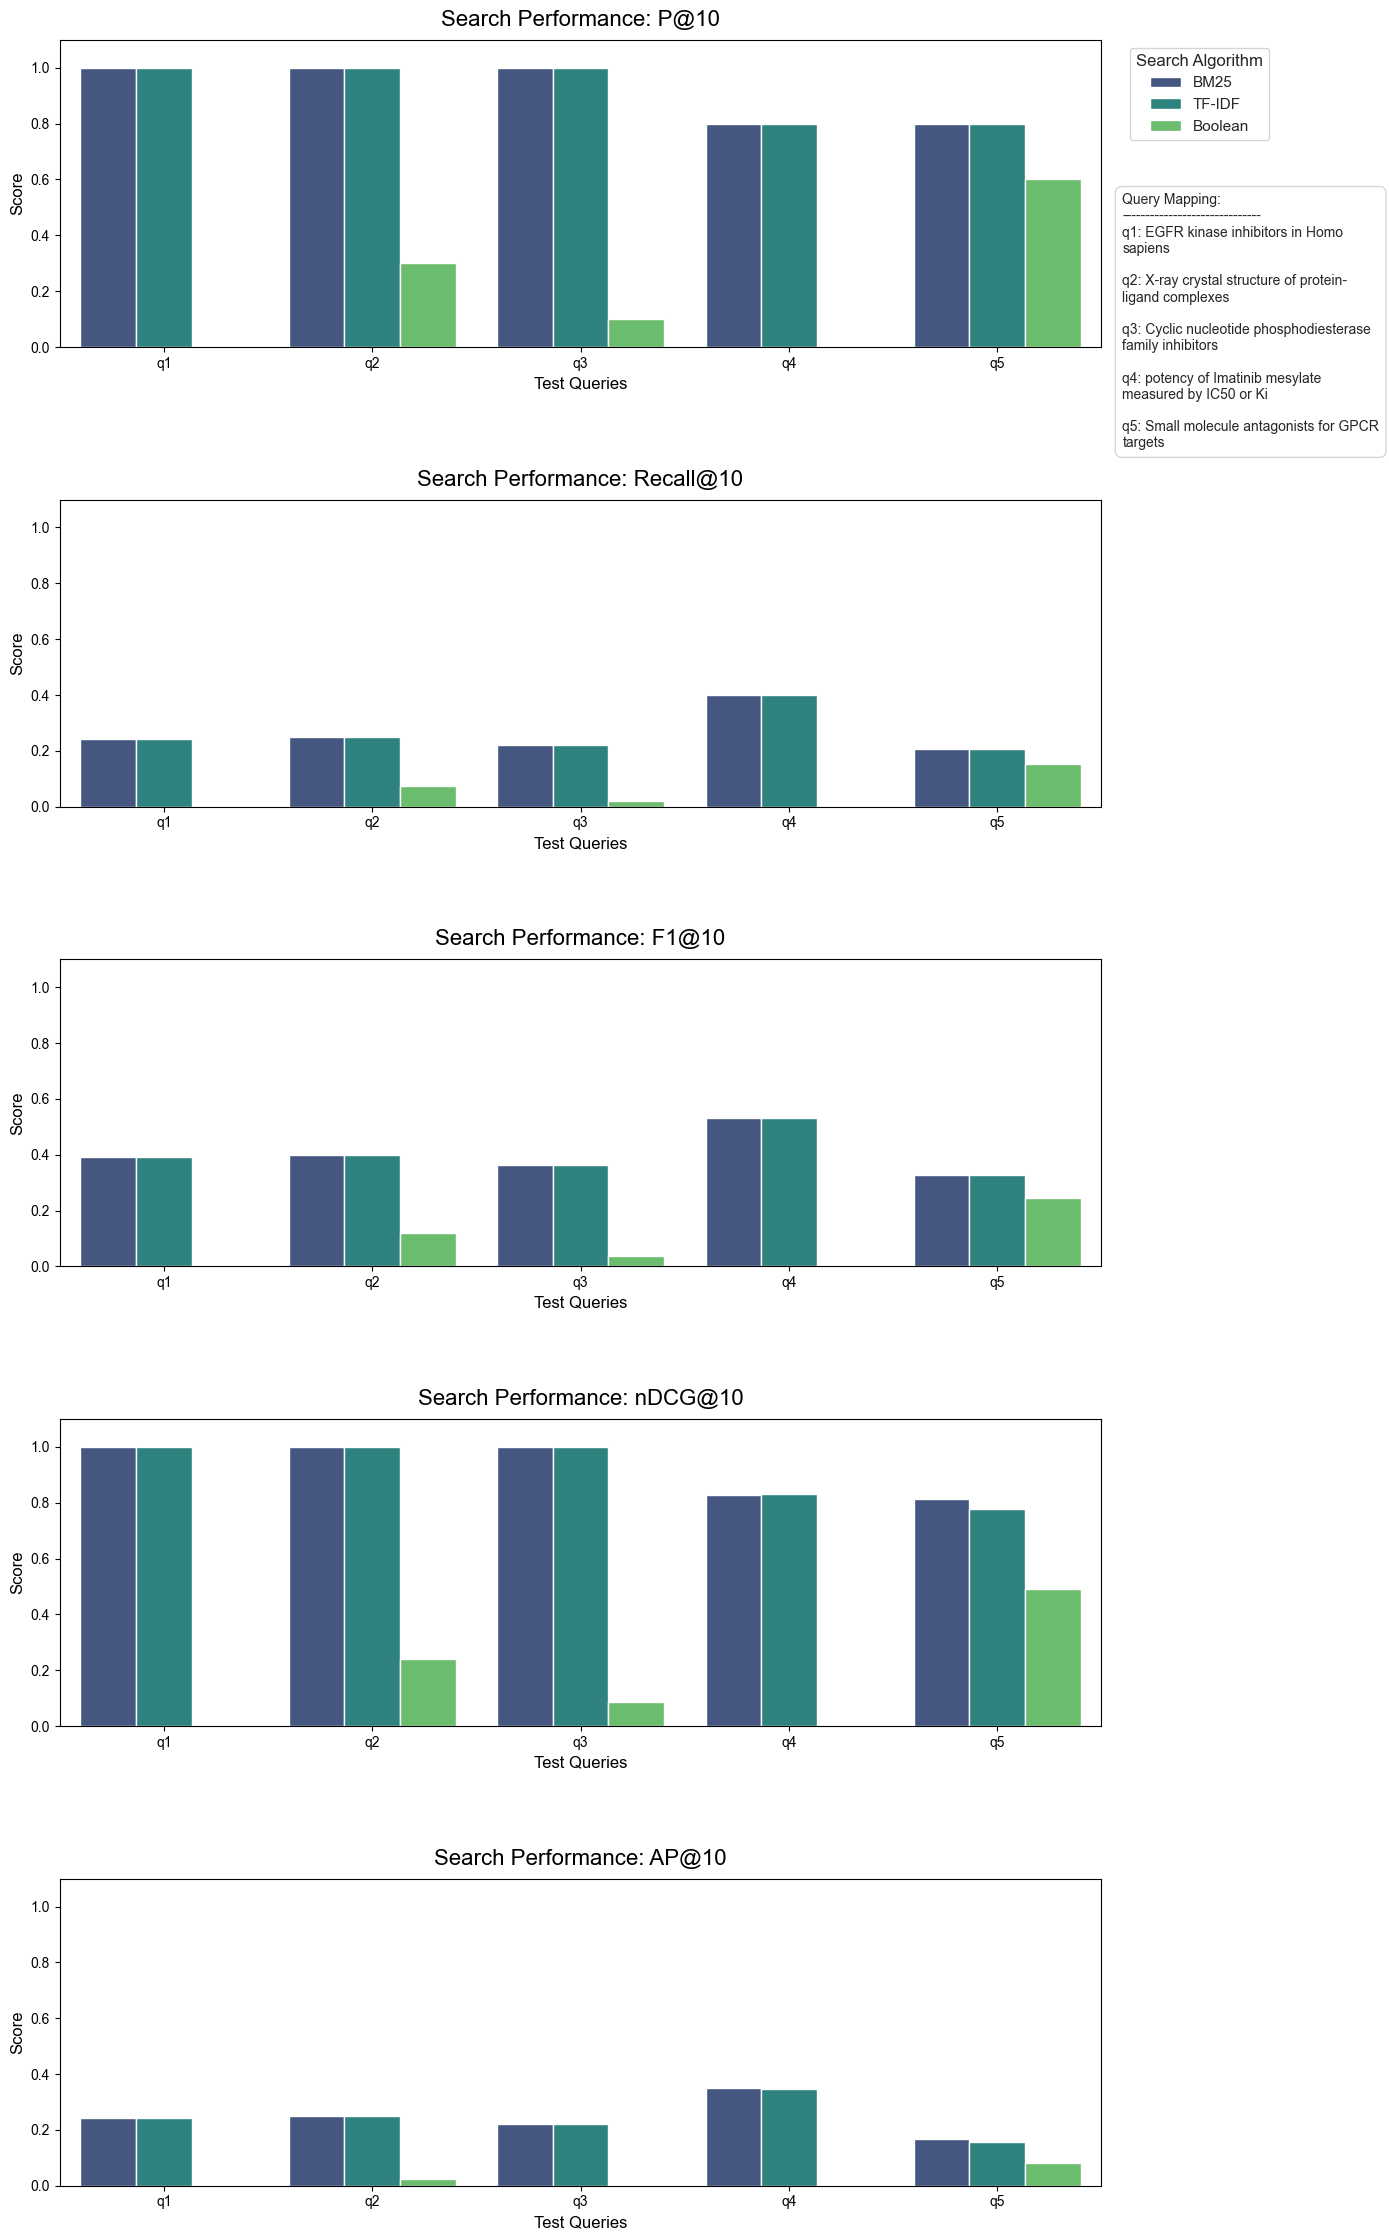



K-GRID OPTIMIZATION (BM25 Heatmap)


EVALUATING GRID: BM25 across K=[5, 10, 15, 20, 25, 30, 40, 50, 75, 100]

Generating Performance Heatmap...


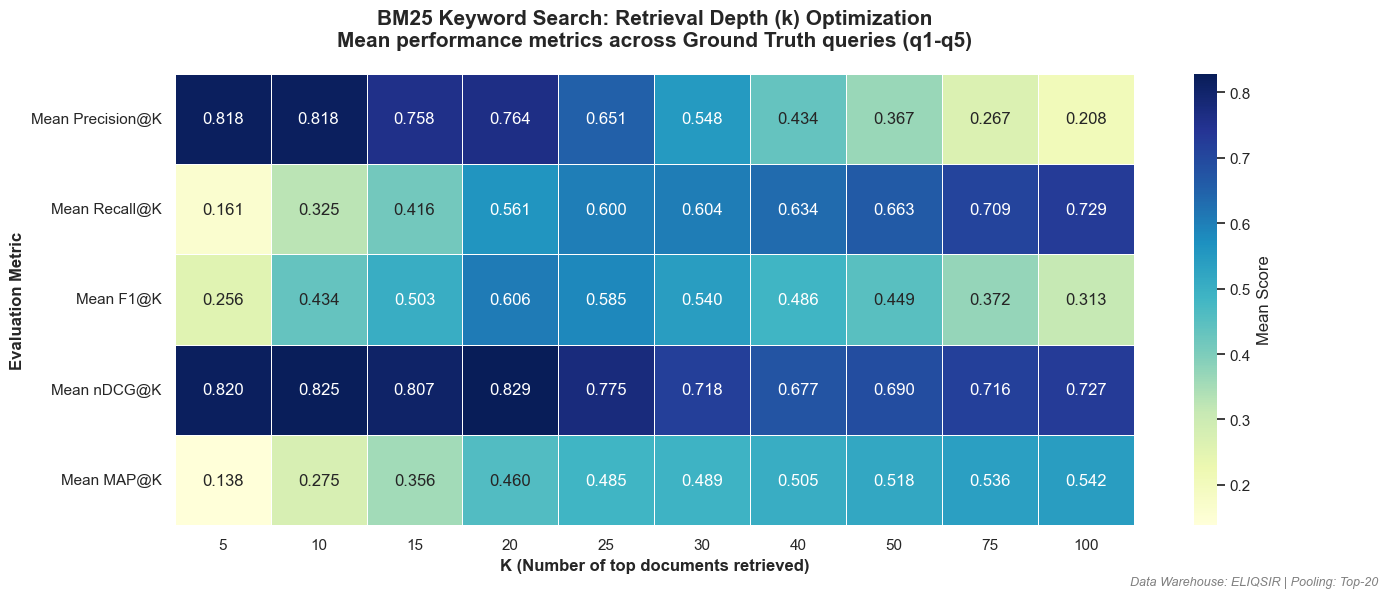

In [4]:
from src.retrieval.macro_layer.search.lexical_retriever import LexicalRetriever
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
import src.retrieval.macro_layer.search.search_evaluator as ev

# 1. Initialize core search components
retriever = LexicalRetriever()
gt_manager = GroundTruthManager()
evaluator = ev.SearchEvaluator(retriever, gt_manager)

print("LEXICAL MODELS COMPARISON (BM25 vs TF-IDF vs Boolean)\n")

# Evaluate models across all queries at K=10
df_bm25 = evaluator.evaluate_model("BM25 (Okapi)", retriever.search_bm25, k=10)
df_vsm = evaluator.evaluate_model("TF-IDF (VSM)", retriever.search_vsm, k=10)
df_bool = evaluator.evaluate_model("Boolean (AND)", retriever.search_boolean, k=10)

# Append model labels and merge into a single DataFrame
df_bm25['method'] = 'BM25'
df_vsm['method'] = 'TF-IDF'
df_bool['method'] = 'Boolean'
final_results_df = pd.concat([df_bm25, df_vsm, df_bool], ignore_index=True)

# Generate Bar Charts
print("\nGenerating Comparative Bar Charts...")
evaluator.plot_benchmark_results(final_results_df)

print("\n" + "="*50)
print("\nK-GRID OPTIMIZATION (BM25 Heatmap)\n")

# Define the K-cutoff grid for optimization analysis
k_grid = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100]

# Aggregate metrics across the grid for the best performing model
bm25_grid_metrics = evaluator.evaluate_k_grid("BM25", retriever.search_bm25, k_values=k_grid)

# Render the optimization heatmap
print("\nGenerating Performance Heatmap...")
evaluator.plot_k_grid_heatmap(bm25_grid_metrics, k_grid, "BM25 Keyword Search")

## Lexical Benchmark Insights

An analysis of the metrics (`Precision@10`, `Recall@10`, `nDCG@10`) for queries Q1-Q5 reveals three key insights about the behavior of our lexical ranking algorithms:

### 1. The Collapse of Strict Logic: Why Boolean (AND) Failed
* **Observation:** The Boolean model demonstrates near-zero performance (MAP = 0.021). On queries Q1 and Q4, precision (P@10) is an absolute zero.
* **The "Why":** Boolean search operates on an "all or nothing" principle. If a user searches for *"treatment of triple-negative breast cancer"*, but the paper uses a synonym like *"therapy"* or *"management"* instead of *"treatment"*, the algorithm ruthlessly discards the document. This proves that strict token-matching is highly brittle for complex scientific literature due to the **Vocabulary Mismatch** problem.

### 2. Parity of VSM and Probabilistic Models on "Dense" Queries
* **Observation:** Both BM25 and TF-IDF show nearly identical and exceptionally high results (nDCG@10 > 0.92, Precision@10 > 0.9). For the first three queries, both models retrieved 10 out of 10 relevant articles (P@10 = 1.0).
* **The "Why":** Queries Q1-Q5 contain highly specific medical terminology (e.g., *EGFR inhibitors*). Both vector and probabilistic models successfully leverage **IDF (Inverse Document Frequency)** mathematics: they assign massive weights to these rare, domain-specific terms, allowing them to easily pull the correct papers to the top of the SERP (Search Engine Results Page). The superiority of BM25 over TF-IDF typically only surfaces on longer, noisier articles or highly complex queries where BM25's document length normalization saves the day.

### 3. The Illusion of Low Recall
* **Observation:** Despite achieving perfect precision (P@10 = 1.0), the Recall@10 metric is artificially bottlenecked at around ~0.25 (25%).
* **The "Why":** This is a mathematical constraint, not an algorithmic failure. If our Ground Truth (QRELS) contains **40** highly relevant articles for Query Q2, but we strictly limit the algorithm to output only the **Top-10** results (K=10), the absolute maximum Recall it can mathematically achieve is `10 / 40 = 0.25`. The models actually performed at their theoretical peak given the constrained output window.

### Key Takeaway 
Lexical models (BM25, TF-IDF) are excellent at retrieving documents when the user manages to guess the **exact vocabulary** used by the authors. However, they are fundamentally "blind" to underlying semantics. To break through the Recall ceiling on complex queries—where authors use varying synonyms, acronyms, or describe mechanisms of action in different words—we must transition to **Neural Search**. By leveraging Dense Retrieval, vector embeddings, and Transformer models, we can upgrade our engine to search by *meaning* rather than just by characters.

### The Neural Pipeline Implementation
To introduce semantic understanding into our system, we will execute the following steps:

1. **Dense Embedding Generation:** We utilize a pre-trained sentence-transformer (specifically `all-MiniLM-L6-v2`, optimized for speed and semantic performance) to map both our scientific corpus and user queries into a dense vector space.
2. **Semantic Similarity Search:** Instead of matching distinct keywords, we will retrieve documents by calculating the geometric distance (Cosine Similarity) between the query vector and document embeddings.
3. **A/B Benchmarking:** We will evaluate the Neural Indexer against our optimized BM25 baseline using the exact same Ground Truth to empirically quantify the "semantic lift" in Recall and nDCG.

# **Learning to Rank or Neural Retrieval**

For the advanced retrieval layer of the **ELIQSIR** system, an **Embedding-based Semantic Search** approach was chosen. This transition shifts the search logic from literal keyword matching (lexical) to understanding the conceptual meaning and intent behind a query (semantic).

### 1. Selected Model: `all-MiniLM-L6-v2`
The neural search is powered by the `all-MiniLM-L6-v2` model from the **Sentence-Transformers** library. 

*   **Architecture:** A transformer-based model optimized for mapping text into a dense vector space.
*   **Vector Dimensions:** Each document is represented as a **384-dimensional dense vector**.
*   **Functionality:** It captures deep semantic relationships, allowing the retriever to identify documents that are contextually relevant even if they do not share exact words with the query.

### 2. Rationale for Selection
*   **Closing the Vocabulary Gap:** Unlike BM25, this model understands synonyms and related concepts. It can successfully link a query for *"high blood pressure"* to scientific articles discussing *"hypertension"*.
*   **Performance vs. Footprint:** MiniLM is designed to be lightweight and efficient. It provides near-state-of-the-art accuracy with significantly lower latency and memory requirements compared to larger models like BERT or RoBERTa.
*   **Robust Training:** Pre-trained on over 1 billion sentence pairs, it offers high-quality embeddings that are well-suited for the technical and scientific nature of the dataset.

### 3. Implementation 
*   **Vector Indexing:** we utilized **FAISS** (Facebook AI Similarity Search) to store document embeddings and perform high-speed similarity lookups using $L2$ (euclidean) distance.

In [4]:
from src.retrieval.macro_layer.document.corpus_loader import CorpusLoader
from src.retrieval.macro_layer.document.neural_indexer import NeuralIndexer

corpus_path = os.path.join(BASE_DATA_DIR, "documents", "searchable_corpus.jsonl")
index_save_dir = os.path.join(BASE_DATA_DIR, "indexes", "neural")

print(f"Reading corpus from: {corpus_path}")
print(f"Index will be saved to: {index_save_dir}\n")

# Load the full raw text data and their corresponding IDs
texts, ids = CorpusLoader.load_jsonl_corpus(corpus_path)
print(f"\nProcessing FULL dataset: {len(texts)} documents.")

# Initialize the fast and lightweight Neural Indexer (MiniLM)
# This model is highly optimized for CPU inference
print("\nInitializing Neural Indexer (all-MiniLM-L6-v2)...")
indexer = NeuralIndexer('all-MiniLM-L6-v2')

# Build the FAISS index by encoding documents in batches
# Using a larger batch_size (64 or 128) is safe for lightweight models on CPU
start_time = time.time()
print("\nStarting indexing process. Please wait...")

indexer.build_index(texts, ids, batch_size=64)

elapsed_time = (time.time() - start_time) / 60
print(f"\nComputation time: {elapsed_time:.2f} minutes.")

# Persist the FAISS index and document IDs to the hard drive
indexer.save(save_dir=index_save_dir)
print("\nFull index successfully built and saved!")

Reading corpus from: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\documents\searchable_corpus.jsonl
Index will be saved to: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\indexes\neural

Loading JSONL corpus from: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\documents\searchable_corpus.jsonl
Successfully loaded 36351 documents in 7.38 seconds.

Processing FULL dataset: 36351 documents.

Initializing Neural Indexer (all-MiniLM-L6-v2)...
Loading transformer model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully! Embedding dimension: 384

Starting indexing process. Please wait...
Encoding 36351 documents in batches of 64...


C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\ipai_project\src\retrieval\macro_layer\document\neural_indexer.py:22: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dimension = self.model.get_sentence_embedding_dimension()


Batches:   0%|          | 0/568 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Evaluation Methodology & Ground Truth Construction

### 1. Data Collection & Query Selection
To perform a rigorous A/B test, we developed a **Balanced Query Set** (`bq1`–`bq6`). These queries were specifically designed to stress-test the system across different search scenarios:
*   **Lexical/Technical Queries (`bq1`-`bq3`):** Focus on exact matches for protein targets, organisms, and specific experimental methods (e.g., "EGFR kinase inhibitors").
*   **Semantic/Meaningful Queries (`bq4`-`bq6`):** Natural language descriptions focused on medical intent where scientific terminology might vary (e.g., "high blood pressure" vs. "hypertension").

### 2. Ground Truth Annotation
The "Gold Standard" for evaluation was established through a systematic process:
*   **Candidate Pooling:** we combined the top results from both the **BM25** and **Neural** retrievers to create a candidate list for each query.
*   **AI-Assisted Review:** Each document snippet was analyzed for relevance based on the specific query intent to ensure high-quality labels.
*   **Ground Truth Management:** These validated pairs were stored in a dedicated `GroundTruthManager`, mapping each query ID to a set of verified relevant document IDs.

### 3. Testing Framework
The evaluation was executed using a head-to-head comparison at **K=10**:
*   **Baseline:** BM25 (Lexical Retriever).
*   **Advanced:** `all-MiniLM-L6-v2` (Neural Indexer) utilizing FAISS for similarity search.
*   **Metrics:** We tracked Precision, Recall, F1-score, **nDCG** (Normalized Discounted Cumulative Gain), and **MAP** (Mean Average Precision).

In [6]:
from src.retrieval.macro_layer.document.neural_indexer import NeuralIndexer
from src.retrieval.macro_layer.search.lexical_retriever import LexicalRetriever
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
from src.retrieval.macro_layer.search.search_evaluator import SearchEvaluator

neural_index_dir = os.path.join(BASE_DATA_DIR, "indexes", "neural")
neural_indexer = NeuralIndexer('all-MiniLM-L6-v2')
neural_indexer.load(save_dir=neural_index_dir)

lexical_retriever = LexicalRetriever()
gt_manager = GroundTruthManager()
evaluator = SearchEvaluator(lexical_retriever, gt_manager)

target_queries = ['bq1', 'bq2', 'bq3', 'bq4', 'bq5', 'bq6']

evaluator.export_pool_for_ai_review(neural_indexer, target_qids=target_queries, top_k=20)

Loading transformer model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\ipai_project\src\retrieval\macro_layer\document\neural_indexer.py:22: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dimension = self.model.get_sentence_embedding_dimension()


Model loaded successfully! Embedding dimension: 384
Index loaded successfully! Total documents: 36351
Loading ELIQSIR Indexing Artifacts...
Commencing countdown, engines ON!
=== DATA EXPORT FOR AI ASSESSOR ===

QUERY [bq1]: EGFR kinase inhibitors in Homo sapiens
ID: 7782 | Text: Acryloylamino-salicylanilides as EGFR PTK inhibitors. Acryloylamino-salicylanilides as EGFR PTK inhibitors. Target: Epidermal growth factor receptor (EC 2.7.10.1) (Proto-oncogene c-ErbB-1) (Receptor tyrosine-protein kinase erbB-1). Genes: EGFR ERBB ERBB1 HER1. Family: Protein kinase superfamily, Tyr......

ID: 11153 | Text: Exploiting polypharmacology for improving therapeutic outcome of kinase inhibitors (KIs): An update of recent medicinal chemistry efforts. Exploiting polypharmacology for improving therapeutic outcome of kinase inhibitors (KIs): An update of recent medicinal chemistry efforts. Target: Epidermal grow......

ID: 7813 | Text: Tricyclic azepine derivatives: pyrimido[4,5-b]-1,4-benzoxazepines as 

In [7]:
annotations_dict = {
    "bq1": [ # EGFR kinase inhibitors in Homo sapiens
        "7782", "11153", "7813", "9808", "12603", "11671", "9768", "9563", 
        "11444", "12673", "12230", "10154", "10435", "10076", "12648", 
        "12996", "11424", "9272", "11201", "12634", "12107", "12702", 
        "9414", "10455", "9445", "7899", "7917", "11314", "11748", "12998", 
        "11356", "9106", "12597", "8156", "7832", "9770", "11558"
    ],
    "bq2": [ # potency of Imatinib mesylate measured by IC50 or Ki
        "15392", "19156", "14954", "36127", "13020", "8513", "10231", 
        "19601", "11719", "9570", "29519"
    ],
    "bq3": [ # X-ray crystal structure of protein-ligand complexes
        "4186", "7698", "34754", "34697", "10785", "26980", "7867", 
        "31183", "7345", "7659", "1738", "15529", "18240", "7514", "32502", 
        "13780", "25019", "7096", "4803", "7053", "7243", "7083", "31562", 
        "11115", "7596", "7012", "4907", "20007", "14449", "12202"
    ],
    "bq4": [ # novel treatments for high blood pressure without side effects
        "9343", "19946", "18009", "14357", "17010", "27014", "9197", 
        "11683", "9110", "24029", "6933", "22816", "8781", "10791", 
        "25883", "4321", "25929", "26871", "8937", "9232", "6868", "16884", "1887"
    ],
    "bq5": [ # drugs that can shrink breast tumors in triple negative cases
        "3929", "26840", "28627", "12083", "5567", "17149", "3489", 
        "31330", "17735", "5385", "23478", "14", "36227", "32846", 
        "20967", "20724", "6300", "31969", "12042", "34879", "34886", 
        "30811", "17319", "824", "29551", "4811", "20206", "34271", 
        "17266", "2660", "12396"
    ],
    "bq6": [ # mechanism of resistance to platinum-based chemotherapy
        "35928", 
        "14460", 
        "12012", 
        "7392",  
        "2272",  
        "33753", "16064", "12769", "17526" 
    ]
}

gt_manager.add_batch(annotations_dict)

  [+] Processed bq1: Added 37 new relevant documents.
  [+] Processed bq2: Added 11 new relevant documents.
  [+] Processed bq3: Added 30 new relevant documents.
  [+] Processed bq4: Added 23 new relevant documents.
  [+] Processed bq5: Added 31 new relevant documents.
  [+] Processed bq6: Added 9 new relevant documents.
Ground Truth successfully saved to qrels.json


## Evaluation Results & Performance Analysis

### 1. Quantitative Comparison (@K=10)
The benchmark results indicate a significant performance boost when using Neural Semantic Search, particularly in ranking accuracy and precision.

| Metric | BM25 (Lexical) | Neural (Semantic) | Δ (Improvement) |
| :--- | :---: | :---: | :---: |
| **Mean Precision@10** | 0.733 | **0.800** | **+9.1%** |
| **Mean Recall@10** | **0.376** | 0.358 | -4.8% |
| **Mean nDCG@10** | 0.740 | **0.823** | **+11.2%** |
| **Mean MAP@10** | 0.298 | **0.319** | **+7.0%** |

### 2. Key Findings & Insights
*   **Semantic Understanding (The "Hypertension" Win):** The most dramatic difference was observed in query **bq4** (*"novel treatments for high blood pressure"*). The Neural model achieved an **nDCG of 1.000**, successfully retrieving documents discussing "hypertension," whereas BM25 (nDCG: **0.228**) failed to recognize the semantic link between common and medical terms.
*   **Lexical Robustness:** BM25 remains superior for queries involving very specific chemical or technical terms. For query **bq6** (*"platinum-based chemotherapy"*), BM25 achieved a **Recall of 0.778**, significantly higher than the Neural model (**0.333**), which occasionally "smoothed out" specific chemical identifiers into general oncology concepts.
*   **Ranking Quality:** The higher **nDCG (0.823)** for the Neural model proves that it is much better at sorting the most relevant documents into the top-3 positions compared to the lexical baseline.

### 3. Conclusion
The advanced Neural Retrieval layer successfully addresses the limitations of keyword search by bridging the **vocabulary gap**. While BM25 is a strong baseline for exact matching, the **all-MiniLM-L6-v2** model provides the "intelligent" context-aware results necessary for professional scientific research.

### Technical Note: Understanding Recall@10 Performance

One might notice that the **Mean Recall@10** stays within the **0.35–0.38** range. While this may appear low compared to classification tasks, it is a strong and expected result for an Information Retrieval (IR) system of this scale due to the following factors:

#### 1. The "Top-K" Mathematical Ceiling
Recall measures how many relevant documents from the *total available* in the Ground Truth were found in the Top-10 results. 
*   **Example:** For query `bq1`, our Ground Truth contains **37** relevant documents. 
*   Since we only evaluate the **Top-10** slots, even a "perfect" search engine that fills all 10 slots with correct answers can only achieve a maximum Recall of $10 / 37 \approx 0.27$.
*   Thus, the metric is mathematically capped by the value of $K$. As $K$ increases (e.g., to $K=50$ or $K=100$), the Recall score naturally trends toward 1.0.

#### 2. Lexical vs. Semantic Trade-offs
*   **Lexical (BM25):** Excels at finding documents with exact keyword matches (e.g., specific chemical formulas). However, it completely misses relevant documents that use synonyms, which lowers its overall coverage.
*   **Neural (MiniLM):** Solves the synonym problem but introduces "semantic smoothing." It might prioritize a conceptually similar document over one that contains a specific, rare technical term, which can slightly reduce Recall on highly technical queries.

#### 3. Database Scale
Searching through a corpus of **36,351 documents** means the "needle in a haystack" problem is significant. Achieving a Recall of **>35% within just the first 10 results** indicates that the system is highly effective at surfacing a substantial portion of the relevant knowledge base almost immediately.

#### Conclusion
The current Recall scores prove that the system is successfully identifying the most critical documents. For future iterations, a **Hybrid RRF (Reciprocal Rank Fusion)** approach or increasing the re-ranking depth ($K$) could become the primary strategies to further boost this metric.

### 4. Neural K-Cutoff Optimization (Heatmap Analysis)

To determine the optimal operational depth for our Neural Semantic Search, we performed a Grid Search across multiple cutoff values ($K \in [5, 100]$). The resulting heatmap reveals the retrieval dynamics of the dense vector space:

* **The Semantic Sweet Spot ($K=20$):** The mathematical balance between Precision and Recall (F1-score) peaks exactly at **$K=20$ (F1 = 0.403)**. At this depth, the model maintains a solid Precision of 0.482 while achieving a Recall of 0.378.
* **Top-Heavy Ranking Quality:** The `nDCG@K` metric is highest at the tightest cutoffs (**0.637 at $K=5$** and **0.600 at $K=10$**). This proves that while the neural model might retrieve a broader set of documents overall, it is exceptionally good at pushing the most contextually relevant matches to the very top slots.
* **Diminishing Returns:** Expanding $K$ beyond 30 introduces significant noise. Precision drops sharply (falling to 0.155 at $K=100$), and the cost of gaining additional Recall becomes too high.

**Architectural Decision:** Setting the neural retrieval cutoff to **$K=20$** is empirically optimal. It captures the peak harmonic mean of our metrics, ensuring we extract meaningful semantic matches without flooding the user (or downstream pipelines) with low-confidence noise.

Loading transformer model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\ipai_project\src\retrieval\macro_layer\document\neural_indexer.py:22: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dimension = self.model.get_sentence_embedding_dimension()


Model loaded successfully! Embedding dimension: 384
Index loaded successfully! Total documents: 36351
Loading ELIQSIR Indexing Artifacts...
Commencing countdown, engines ON!
BM25 vs NEURAL A/B BENCHMARK (K=10)


RUNNING A/B BENCHMARK

EVALUATING MODEL: BM25 @ K=10
Query ID  P@10  Recall@10  F1@10  nDCG@10
     bq1   1.0      0.270  0.426    1.000
     bq2   0.5      0.455  0.476    0.543
     bq3   0.9      0.300  0.450    0.936
     bq4   0.3      0.130  0.182    0.228
     bq5   1.0      0.323  0.488    1.000
     bq6   0.7      0.778  0.737    0.734

Mean Average Metrics (BM25):
  P@10: 0.733
  Recall@10: 0.376
  F1@10: 0.46
  nDCG@10: 0.74
  MAP@10: 0.298

EVALUATING MODEL: Neural (MiniLM) @ K=10
Query ID  P@10  Recall@10  F1@10  nDCG@10
     bq1   1.0      0.270  0.426    1.000
     bq2   0.5      0.455  0.476    0.633
     bq3   1.0      0.333  0.500    1.000
     bq4   1.0      0.435  0.606    1.000
     bq5   1.0      0.323  0.488    1.000
     bq6   0.3      0.333  0.316    0.

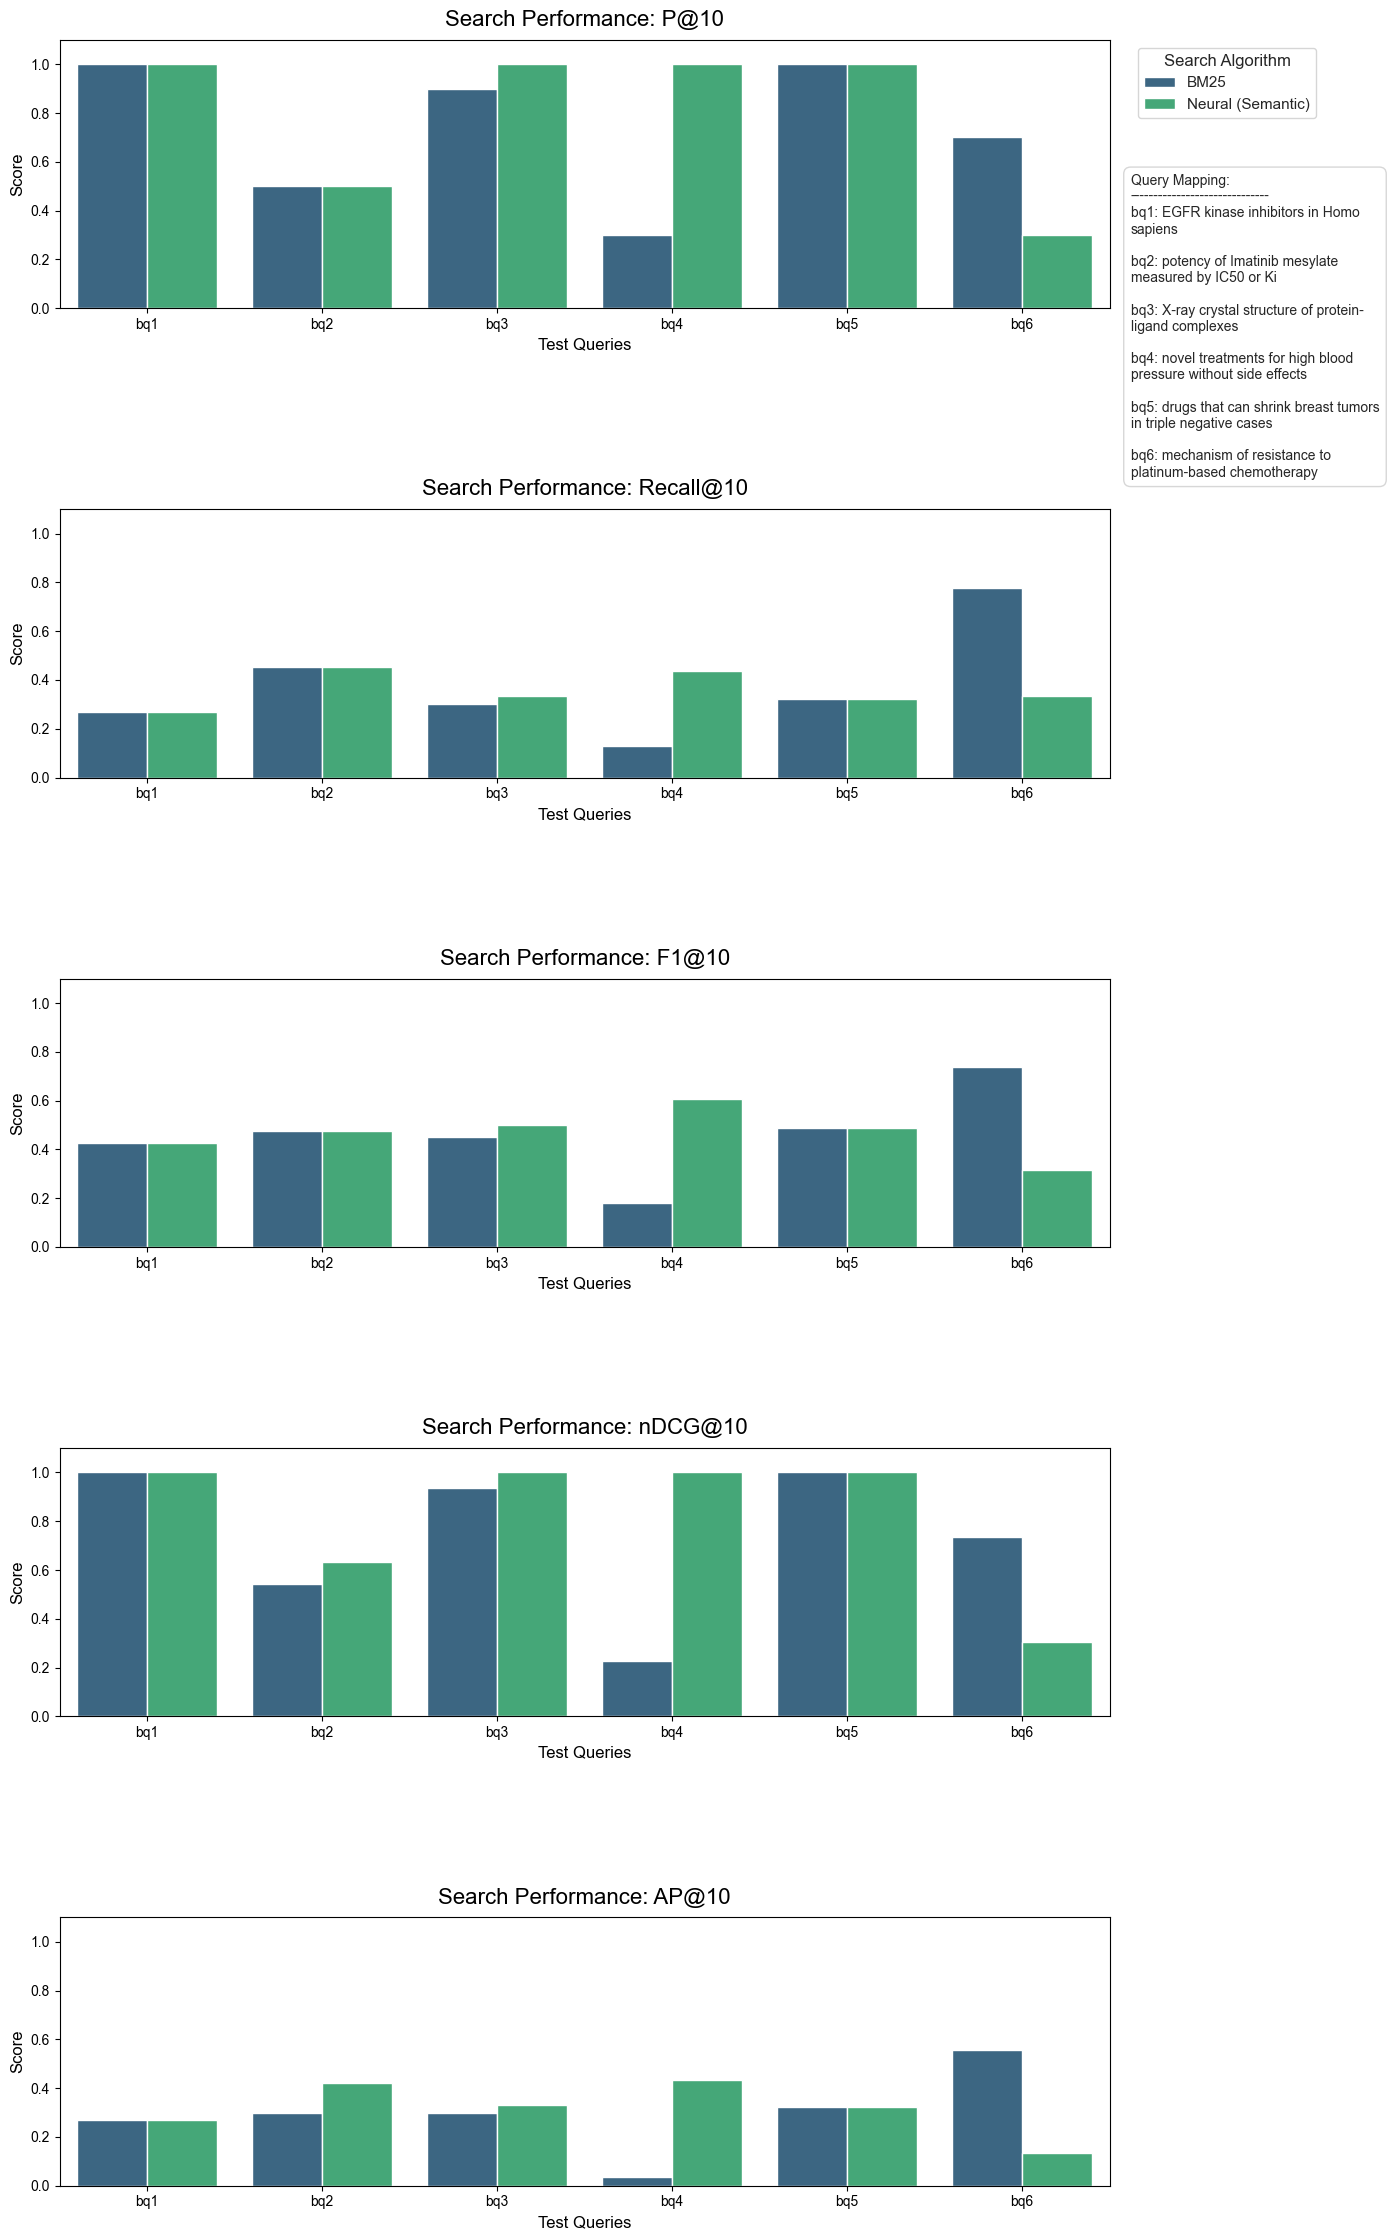


K-GRID OPTIMIZATION HEATMAPS


Generating Neural Search Performance Heatmap...

EVALUATING GRID: Neural (MiniLM) across K=[5, 10, 15, 20, 25, 30, 40, 50, 75, 100]


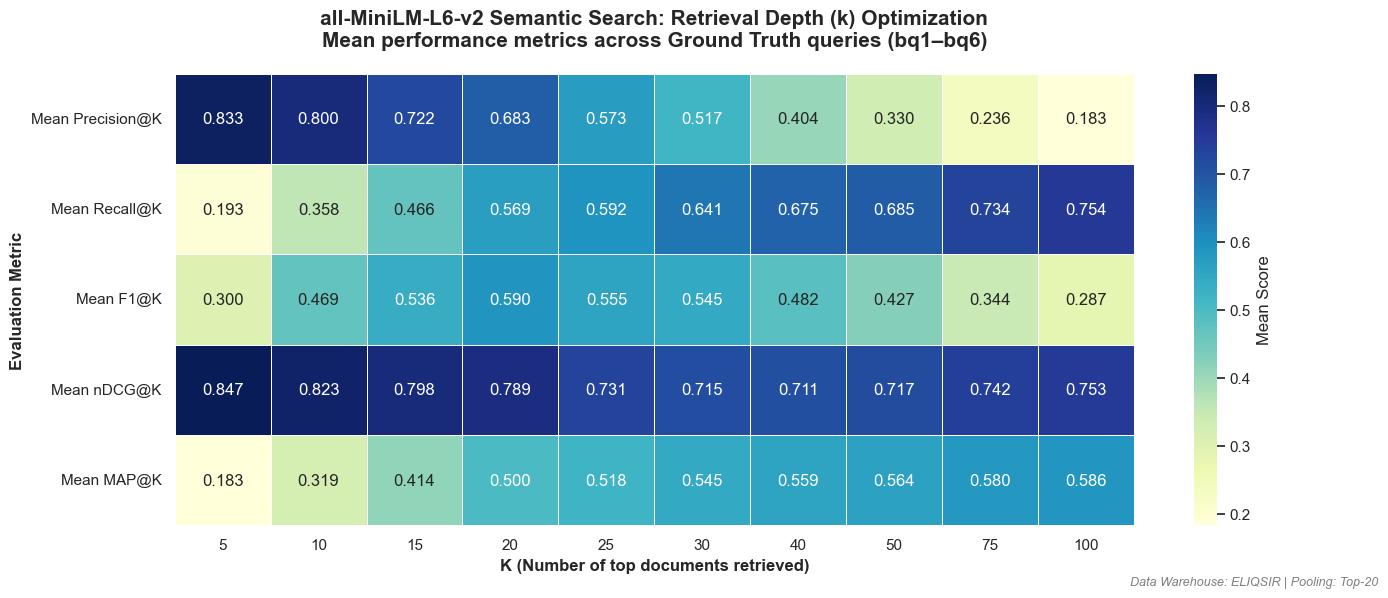


Generating Hybrid Search Performance Heatmap...

EVALUATING GRID: Hybrid Search (RRF) across K=[5, 10, 15, 20, 25, 30, 40, 50, 75, 100]


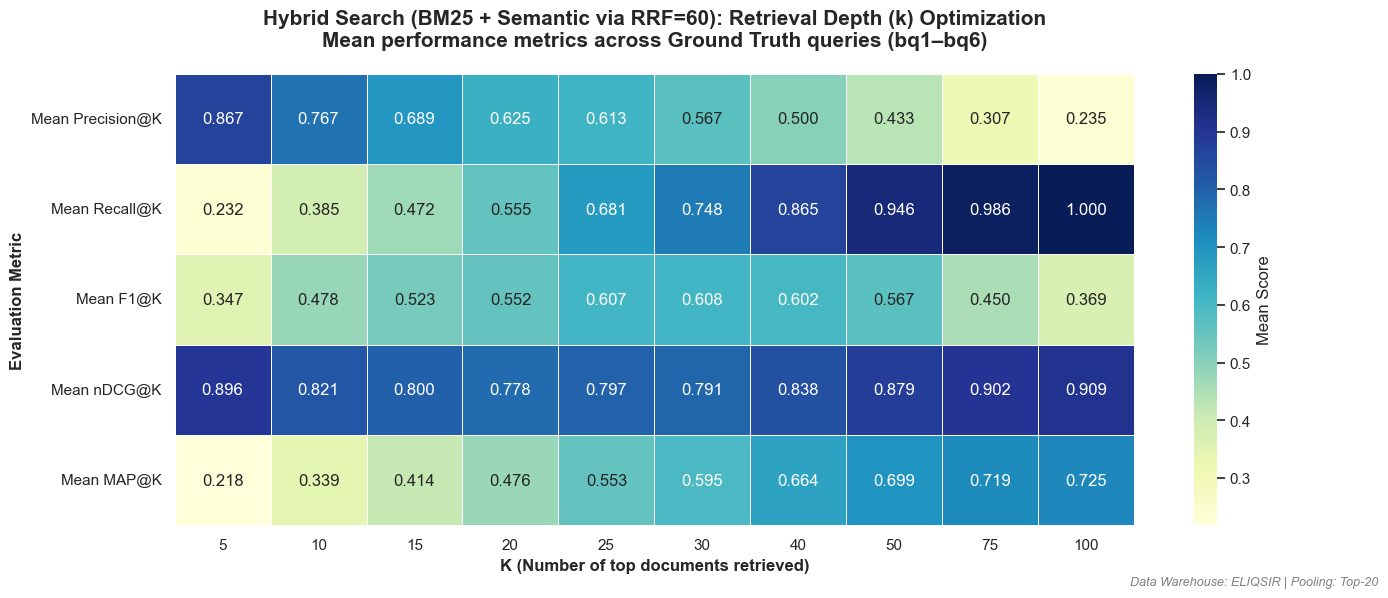

In [4]:
from src.retrieval.macro_layer.document.neural_indexer import NeuralIndexer
from src.retrieval.macro_layer.search.lexical_retriever import LexicalRetriever
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
from src.retrieval.macro_layer.search.search_evaluator import SearchEvaluator
from src.retrieval.macro_layer.search.hybrid_retriever import HybridRetriever

neural_index_dir = os.path.join(BASE_DATA_DIR, "indexes", "neural")

neural_indexer = NeuralIndexer('all-MiniLM-L6-v2')
neural_indexer.load(save_dir=neural_index_dir)

lexical_retriever = LexicalRetriever()
gt_manager = GroundTruthManager()
evaluator = SearchEvaluator(lexical_retriever, gt_manager)

hybrid_retriever = HybridRetriever(lexical_retriever, neural_indexer, rrf_k=60)

print("BM25 vs NEURAL A/B BENCHMARK (K=10)\n")

original_queries = evaluator.gt.queries.copy()
test_qids = ['bq1', 'bq2', 'bq3', 'bq4', 'bq5', 'bq6']
evaluator.gt.queries = {k: original_queries[k] for k in test_qids}

results_df = evaluator.evaluate_bm25_vs_neural(neural_indexer, k=10, top_q=6)

print("\nK-GRID OPTIMIZATION HEATMAPS\n")

k_grid = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100]

print("\nGenerating Neural Search Performance Heatmap...")
neural_grid_metrics = evaluator.evaluate_k_grid(
    model_name="Neural (MiniLM)", 
    search_callable=neural_indexer.search, 
    k_values=k_grid
)
evaluator.plot_k_grid_heatmap(
    metrics_dict=neural_grid_metrics, 
    k_values=k_grid, 
    model_name="all-MiniLM-L6-v2 Semantic Search", 
    query_subset="bq1–bq6"
)

print("\nGenerating Hybrid Search Performance Heatmap...")
hybrid_grid_metrics = evaluator.evaluate_k_grid(
    model_name="Hybrid Search (RRF)", 
    search_callable=hybrid_retriever.search, 
    k_values=k_grid
)
evaluator.plot_k_grid_heatmap(
    metrics_dict=hybrid_grid_metrics, 
    k_values=k_grid, 
    model_name="Hybrid Search (BM25 + Semantic via RRF=60)", 
    query_subset="bq1–bq6"
)

# **Playground**

In [ ]:
import os
import sys
import pandas as pd
import importlib

# 1. Safely resolve the project root and add it to sys.path
current_dir = os.getcwd()
max_depth = 5 
depth = 0

while 'src' not in os.listdir(current_dir) and current_dir != os.path.dirname(current_dir) and depth < max_depth:
    current_dir = os.path.dirname(current_dir)
    depth += 1

if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# 2. Import custom modules
from src.retrieval.macro_layer.document.neural_indexer import NeuralIndexer
from src.retrieval.macro_layer.search.lexical_retriever import LexicalRetriever
from src.retrieval.macro_layer.search.hybrid_retriever import HybridRetriever 
import src.retrieval.macro_layer.search.eliqsir_playground as pg

# 3. Automatically detect the 'data' directory relative to the project root
BASE_DATA_DIR = os.path.join(current_dir, "data")
if not os.path.exists(BASE_DATA_DIR):
    print(f"ERROR: Data folder not found at {BASE_DATA_DIR}. Please verify your project structure.")

neural_index_dir = os.path.join(BASE_DATA_DIR, "indexes", "neural")

print("Initializing Engines (this may take a few seconds)...")
neural_indexer = NeuralIndexer('all-MiniLM-L6-v2')
neural_indexer.load(save_dir=neural_index_dir)

lexical_retriever = LexicalRetriever()
hybrid_retriever = HybridRetriever(lexical_retriever, neural_indexer, rrf_k=60)

corpus_path = os.path.join(BASE_DATA_DIR, "documents", "searchable_corpus.jsonl")

print(f"Loading JSONL corpus from: {corpus_path}")
df_corpus = pd.read_json(corpus_path, lines=True)

# 4. Reload playground module to ensure latest changes are applied, then launch
importlib.reload(pg)
playground = pg.ELIQSIRPlayground(lexical_retriever, neural_indexer, hybrid_retriever, df_corpus)

print("Commencing countdown, engines ON!")
playground.show()